In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Loads the consolidated CSVs from a single congestion-experiment run. Default to the notebook's
# directory (so dropping CSVs next to the .ipynb works without setup); fall back to the most recent
# network_sink_run_* dir at the repo root.
def _default_results_dir():
    here = os.path.abspath('.')
    if os.path.exists(os.path.join(here, 'network_sending_timeseries.csv')):
        return here
    repo_root = os.path.abspath(os.path.join(here, os.pardir, os.pardir, os.pardir, os.pardir))
    import glob as _glob
    candidates = sorted(_glob.glob(os.path.join(repo_root, 'network_sink_run_*')))
    return candidates[-1] if candidates else here

_CAP_RE = re.compile(r'^(?P<num>\d+(?:\.\d+)?)(?P<si>[kmg]?)(?P<base>bit|bps)$', re.IGNORECASE)
def _cap_sort_key(cap):
    """Sort tc rate strings ('500kbit', '1mbit', '2mbit') by their bit/s magnitude."""
    if cap == 'none':
        return float('inf')
    m = _CAP_RE.fullmatch(str(cap).strip())
    if not m:
        return float('inf')
    mult = {'': 1, 'k': 1e3, 'm': 1e6, 'g': 1e9}[m.group('si').lower()]
    bits = float(m.group('num')) * mult
    return bits * (8 if m.group('base').lower() == 'bps' else 1)


# Window resolution used by the benchmark when binning listener events (must match
# NETWORK_EVENTS_WINDOW_MS in scripts/benchmarking/network_sink/config.py).
WINDOW_MS = 100


def _fill_runtime_grid(df, metric_cols):
    """Reindex each (run_idx, strategy, cap, priority) group to a complete runtime_s grid at
    WINDOW_MS resolution. Missing samples for the listed *metric_cols* are filled with 0; other
    per-row columns (e.g. max_network_rate_tuples_per_s) are forward/back-filled from neighbors so
    the cap stays constant within a group. The runtime_s axis runs from 0 to the group's max
    observed runtime_s — gaps inside that range get filled, but we don't extrapolate beyond it.
    """
    if df.empty:
        return df
    pieces = []
    for keys, group in df.groupby(['run_idx', 'strategy', 'cap', 'high_label', 'low_label', 'priority'], sort=False):
        group = (group
                 .sort_values('runtime_s')
                 .assign(runtime_ms=lambda d: (d['runtime_s'] * 1000).round().astype(int))
                 .drop_duplicates('runtime_ms', keep='last'))
        if group.empty:
            continue
        max_ms = int(group['runtime_ms'].max())
        full_grid_ms = np.arange(0, max_ms + WINDOW_MS, WINDOW_MS)
        idx = group.set_index('runtime_ms').reindex(full_grid_ms)
        for col, val in zip(['run_idx', 'strategy', 'cap', 'high_label', 'low_label', 'priority'], keys):
            idx[col] = val
        for col in idx.columns:
            if col in metric_cols:
                idx[col] = idx[col].fillna(0)
            elif col != 'runtime_s':
                idx[col] = idx[col].ffill().bfill()
        idx['runtime_s'] = idx.index / 1000.0
        pieces.append(idx.reset_index(drop=True))
    return pd.concat(pieces, ignore_index=True) if pieces else df.iloc[0:0]


RESULTS_DIR = _default_results_dir()
print(f'Loading from: {RESULTS_DIR}')

throughput_df = pd.read_csv(os.path.join(RESULTS_DIR, 'throughput_timeseries.csv'))
latency_df    = pd.read_csv(os.path.join(RESULTS_DIR, 'latency_timeseries.csv'))
network_df    = pd.read_csv(os.path.join(RESULTS_DIR, 'network_sending_timeseries.csv'))
# sojourn_timeseries.csv is produced by the C++ BufferSojourn event pipeline: per-window mean
# engine-side queueing delay per priority. Optional — older results dirs predate it.
_sojourn_path = os.path.join(RESULTS_DIR, 'sojourn_timeseries.csv')
sojourn_df    = pd.read_csv(_sojourn_path) if os.path.exists(_sojourn_path) else pd.DataFrame()
# blocked_timeseries.csv is produced by the C++ BackpressureBlocked event pipeline: per-window
# fraction of source-blocked time per priority (0..1). Complementary to sojourn — captures the
# upstream side of backpressure that sojourn is blind to. Optional for older results dirs.
_blocked_path = os.path.join(RESULTS_DIR, 'blocked_timeseries.csv')
blocked_df    = pd.read_csv(_blocked_path) if os.path.exists(_blocked_path) else pd.DataFrame()
# gated_timeseries.csv is produced by the C++ SchedulerGated event pipeline: per-window fraction
# of sink-side scheduler-gated time per priority (0..1). Captures AdaptiveSendingScheduler deny/
# retry loops that the blocked metric misses (those gates don't close the channel, so the source-
# side wait never fires). Optional for older results dirs.
_gated_path = os.path.join(RESULTS_DIR, 'gated_timeseries.csv')
gated_df      = pd.read_csv(_gated_path) if os.path.exists(_gated_path) else pd.DataFrame()

# Fill gaps so the plotted curves don't jump across missing windows; missing metric values become 0.
throughput_df = _fill_runtime_grid(throughput_df, {'throughput_tuples_per_s', 'high_only_tuples_per_s'})
latency_df    = _fill_runtime_grid(latency_df,    {'latency_seconds', 'high_only_latency_seconds'})
network_df    = _fill_runtime_grid(network_df,    {'delivered_tuples_per_s', 'high_only_tuples_per_s'})
if not sojourn_df.empty:
    sojourn_df = _fill_runtime_grid(sojourn_df, {'sojourn_seconds', 'high_only_sojourn_seconds'})
if not blocked_df.empty:
    blocked_df = _fill_runtime_grid(blocked_df, {'blocked_fraction', 'high_only_blocked_fraction'})
if not gated_df.empty:
    gated_df = _fill_runtime_grid(gated_df, {'gated_fraction', 'high_only_gated_fraction'})

spawn_path = os.path.join(RESULTS_DIR, 'low_spawn_schedule.csv')
spawn_df = pd.read_csv(spawn_path) if os.path.exists(spawn_path) else pd.DataFrame()
if not spawn_df.empty:
    spawn_df['spawn_offset_s'] = spawn_df['spawn_offset_ms'] / 1000.0

caps = sorted(network_df['cap'].dropna().unique().tolist(), key=_cap_sort_key)
strategies = sorted(network_df['strategy'].dropna().unique().tolist())
print({
    'caps': caps,
    'strategies': strategies,
    'throughput_rows': len(throughput_df),
    'latency_rows': len(latency_df),
    'network_rows': len(network_df),
    'sojourn_rows': len(sojourn_df),
    'blocked_rows': len(blocked_df),
    'gated_rows': len(gated_df),
    'spawns': len(spawn_df),
})
network_df.head()


Loading from: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/network_sink/plots
{'caps': ['1mbit', 'none'], 'strategies': ['ALWAYS_SEND', 'HIGH_ALONE', 'WEIGHTED_PRIO', 'WEIGHTED_STRICT'], 'throughput_rows': 14412, 'latency_rows': 14487, 'network_rows': 14382, 'sojourn_rows': 14492, 'blocked_rows': 11580, 'gated_rows': 7675, 'spawns': 18}


,run_idx,strategy,cap,max_network_rate_tuples_per_s,high_label,low_label,high_step_high_rate,high_step_low_rate,high_step_period_high,high_step_period_low,low_emit_rate,runtime_s,priority,delivered_tuples_per_s,high_only_tuples_per_s
0,0,HIGH_ALONE,1mbit,15625.0,underloaded,none,7812.5,3906.25,5.0,5.0,NaN,0.0,HIGH,0.0,0.0
1,0,HIGH_ALONE,1mbit,15625.0,underloaded,none,7812.5,3906.25,5.0,5.0,NaN,0.1,HIGH,0.0,0.0
2,0,HIGH_ALONE,1mbit,15625.0,underloaded,none,7812.5,3906.25,5.0,5.0,NaN,0.2,HIGH,0.0,0.0
3,0,HIGH_ALONE,1mbit,15625.0,underloaded,none,7812.5,3906.25,5.0,5.0,NaN,0.3,HIGH,0.0,0.0
4,0,HIGH_ALONE,1mbit,15625.0,underloaded,none,7812.5,3906.25,5.0,5.0,NaN,0.4,HIGH,0.0,0.0


In [2]:
# Per-cap twin-grid renderer. For each (cap × policy) we produce one figure with an
# (HIGH staircase × LOW emit rate) grid of continuous-time-series subplots. HIGH-alone is
# overlaid as a darker dashed reference in every cell of its row.
#
# Note: the tc wire cap is NOT plotted as a reference line. In this engine config the source-side
# backpressure cycle limits effective throughput to ~50% of any tc cap, so HIGH-alone (not the wire
# cap) is the meaningful achievable-throughput baseline. The y-axis is sized to HIGH-alone so
# the share story is the visual focus.
%matplotlib inline

# Per-priority colors. HIGH = red, LOW = blue. HIGH-alone = darker gray with extra weight so it
# stays readable under the colored curves.
PRIORITY_COLORS = {'HIGH': 'tab:red', 'LOW': 'tab:blue'}
HIGH_ALONE_COLOR = '#444'

# Smoothing: centered rolling mean over N WINDOW_MS bins. 10 → 1 s window.
SMOOTHING_WINDOW_SAMPLES = 20  # 2 s rolling window — flattens source-bp-cycle artifacts in saturated rows

# Y-axis ceiling as a fraction of HIGH-alone's peak (since HIGH-alone, not the tc cap, is the real
# achievable-throughput baseline here). Fallback if HIGH-alone is missing.
Y_LIM_FACTOR_OVER_HIGH_ALONE = 1.15
THROUGHPUT_Y_LIM_FALLBACK = 20000

# Twin-grid policies. ADAPTIVE first (headline); ALWAYS_SEND second (comparator).
POLICY_ORDER = ['WEIGHTED_STRICT', 'WEIGHTED_PRIO', 'ALWAYS_SEND']

# Paper-friendly display labels for the policies. CSV values stay as the internal POLICY_ORDER
# keys; only what the reader sees on plot titles / column headers changes. Used by plot_grid's
# suptitle and by the headline / selection-plot header dicts in later cells.
POLICY_DISPLAY_LABEL = {
    'WEIGHTED_STRICT': 'Weighted (100% High)',
    'WEIGHTED_PRIO':   'Weighted (95% High)',
    'ALWAYS_SEND':     'Always Send (TCP-Fair)',
}


def _smoothed_curve(df, value_col):
    sub = df.dropna(subset=[value_col]).sort_values('runtime_s').copy()
    if SMOOTHING_WINDOW_SAMPLES > 1 and len(sub) > 1:
        sub[value_col] = (sub[value_col]
                          .rolling(SMOOTHING_WINDOW_SAMPLES, center=True, min_periods=1)
                          .mean())
    return sub[['runtime_s', value_col]]


def _zero_fill(curve, runtime_max):
    """If *curve* covers less than *runtime_max* seconds, extend it to the right with zeros at
    WINDOW_MS-spaced bins. Used for LOW under ADAPTIVE where gated buffers produce no events:
    without zero-fill the LOW line stops mid-plot, hiding the visual evidence that LOW = 0.
    """
    if curve.empty:
        # No data at all → synthesize a flat-zero line across the full duration.
        ts = list(range(0, int(runtime_max * 1000) + WINDOW_MS, WINDOW_MS))
        return pd.DataFrame({'runtime_s': [t / 1000 for t in ts],
                             curve.columns[1] if len(curve.columns) > 1 else 'value': [0.0] * len(ts)})
    last_t = curve['runtime_s'].max()
    if last_t >= runtime_max - 0.001:
        return curve
    value_col = curve.columns[-1]
    extra_ts = list(range(int(last_t * 1000) + WINDOW_MS, int(runtime_max * 1000) + WINDOW_MS, WINDOW_MS))
    if not extra_ts:
        return curve
    extra = pd.DataFrame({'runtime_s': [t / 1000 for t in extra_ts],
                          value_col: [0.0] * len(extra_ts)})
    return pd.concat([curve, extra], ignore_index=True)


def _phase_boundaries(period_high, period_low, runtime_max):
    """Return phase-boundary times within [0, runtime_max] for vertical separators.
    Boundaries fall at the end of each high phase and each low phase.
    """
    boundaries = []
    t = period_high  # first transition: end of initial high phase
    cycle_idx = 0
    while t < runtime_max:
        boundaries.append(t)
        # alternate: after a high we add period_low, after a low we add period_high
        if cycle_idx % 2 == 0:
            t += period_low
        else:
            t += period_high
        cycle_idx += 1
    return boundaries


def plot_grid(cap, policy, df_metric, value_col):
    """Render one figure (cap, policy) on the (HIGH × LOW) grid.

    df_metric is the time-series dataframe (network_df / throughput_df / latency_df).
    value_col is the metric column to plot.
    Returns the matplotlib Figure (or None if there's no data for this cell).
    """
    cap_mask = df_metric['cap'] == cap
    sub = df_metric[cap_mask]
    if sub.empty:
        return None

    high_labels = list(dict.fromkeys(sub['high_label'].dropna().tolist()))
    low_labels = [l for l in dict.fromkeys(sub['low_label'].dropna().tolist()) if l != 'none']
    if not high_labels or not low_labels:
        return None

    n_rows = len(high_labels)
    n_cols = len(low_labels)

    # HIGH_ALONE references (one curve per HIGH config; overlaid in every column of its row).
    # Collected up-front so they also drive the y-axis ceiling (HIGH-alone IS the achievable
    # throughput here — tc cap is way above what the engine can actually push).
    high_alone_by_label = {}
    high_alone_peak = 0.0
    for high_label in high_labels:
        ha_sub = sub[(sub['strategy'] == 'HIGH_ALONE') & (sub['high_label'] == high_label)
                     & (sub['priority'] == 'HIGH')]
        if not ha_sub.empty:
            curve = _smoothed_curve(ha_sub, value_col)
            high_alone_by_label[high_label] = curve
            if not curve.empty:
                high_alone_peak = max(high_alone_peak, float(curve[value_col].max()))

    y_top = (high_alone_peak * Y_LIM_FACTOR_OVER_HIGH_ALONE) if high_alone_peak > 0 else THROUGHPUT_Y_LIM_FALLBACK

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.0 * n_rows),
                             sharex=True, sharey='row', squeeze=False)

    legend_handles, legend_labels = None, None

    for r, high_label in enumerate(high_labels):
        for c, low_label in enumerate(low_labels):
            ax = axes[r, c]
            cell = sub[(sub['strategy'] == policy) & (sub['high_label'] == high_label)
                       & (sub['low_label'] == low_label)]
            if cell.empty:
                ax.set_title(f'{high_label} × {low_label}\n(no data)', fontsize=9)
                continue

            # Determine trial duration so we can zero-fill curves that don't reach the end.
            runtime_max = cell['runtime_s'].max()
            ha = high_alone_by_label.get(high_label)
            if ha is not None and not ha.empty:
                runtime_max = max(runtime_max, ha['runtime_s'].max())

            # Phase boundary vertical separators. period_high / period_low come from the cell rows
            # (constant across rows of a given high_label); pull the first non-null value.
            ph = cell['high_step_period_high'].dropna()
            pl = cell['high_step_period_low'].dropna()
            if not ph.empty and not pl.empty:
                period_high = float(ph.iloc[0])
                period_low = float(pl.iloc[0])
                for tb in _phase_boundaries(period_high, period_low, runtime_max):
                    ax.axvline(tb, linestyle='-', color='lightgray', alpha=0.5, linewidth=0.7, zorder=0)

            # HIGH and LOW curves; zero-fill so a gated LOW shows a visible flat-0 line through
            # the full plot rather than dropping off where its events stopped.
            for prio in ['HIGH', 'LOW']:
                pcurve = _smoothed_curve(cell[cell['priority'] == prio], value_col)
                pcurve = _zero_fill(pcurve, runtime_max)
                if not pcurve.empty:
                    ax.plot(pcurve['runtime_s'], pcurve[value_col],
                            label=prio, color=PRIORITY_COLORS[prio], linewidth=1.7,
                            zorder=3 if prio == 'HIGH' else 2)

            # HIGH-alone reference: darker gray, slightly thicker so it stays readable under HIGH.
            if ha is not None and not ha.empty:
                ax.plot(ha['runtime_s'], ha[value_col],
                        label='HIGH-alone', color=HIGH_ALONE_COLOR, linewidth=1.4,
                        linestyle='--', alpha=0.85, zorder=1)

            ax.set_title(f'{high_label} × {low_label}', fontsize=10)
            ax.set_ylim(top=y_top, bottom=0)
            ax.grid(True, alpha=0.3)
            if legend_handles is None:
                handles, labels = ax.get_legend_handles_labels()
                if handles:
                    legend_handles, legend_labels = handles, labels

    # Row label as a left-edge text annotation; y-axis label on left column is just the metric.
    for r, high_label in enumerate(high_labels):
        axes[r, 0].set_ylabel('delivered [tup/s]', fontsize=9)
        axes[r, 0].annotate(high_label, xy=(-0.22, 0.5), xycoords='axes fraction',
                            ha='center', va='center', rotation=90, fontsize=10, fontweight='bold')
    for c in range(n_cols):
        axes[-1, c].set_xlabel('runtime [s]')

    smoothing = (f' [smoothed {SMOOTHING_WINDOW_SAMPLES * WINDOW_MS / 1000:g}s rolling]'
                 if SMOOTHING_WINDOW_SAMPLES > 1 else '')
    # Single figure-level legend above the suptitle (replaces the per-subplot legend that used to
    # only render in the top-right cell).
    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc='upper center', ncol=len(legend_handles),
                   bbox_to_anchor=(0.5, 0.99), fontsize=9, frameon=False)
    policy_display = POLICY_DISPLAY_LABEL.get(policy, policy)
    fig.suptitle(f'{policy_display} — cap {cap}{smoothing} '
                 f'(red=HIGH, blue=LOW, dark dashed=HIGH-alone = engine-limited achievable throughput, '
                 f'light verticals=phase boundaries)',
                 fontsize=11, y=0.94)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    return fig

Rendering grids for caps: ['1mbit', 'none']
  wrote congestion_grid_1mbit_weighted_strict.pdf


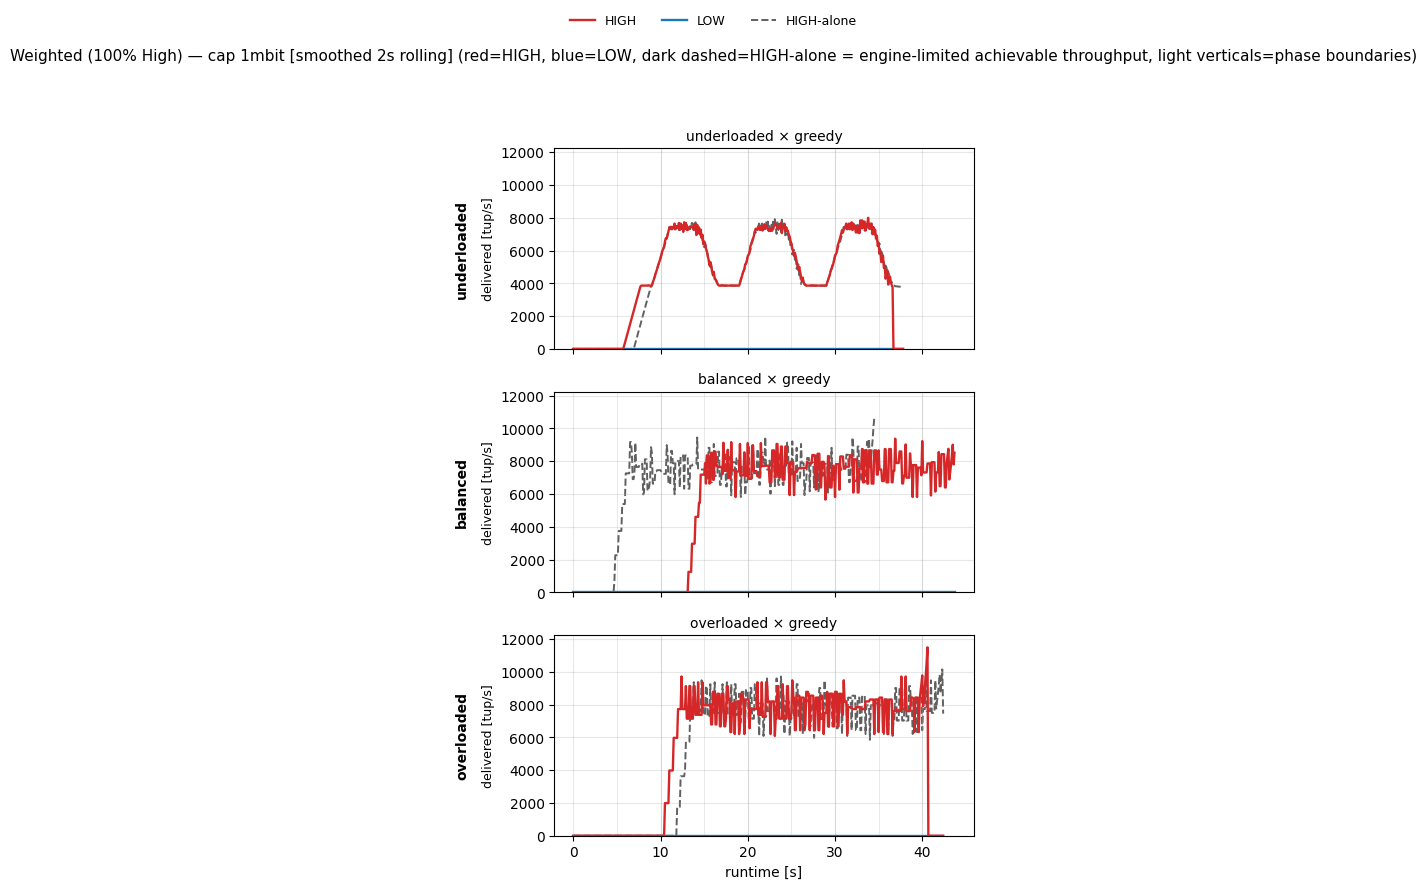

  wrote congestion_grid_1mbit_weighted.pdf


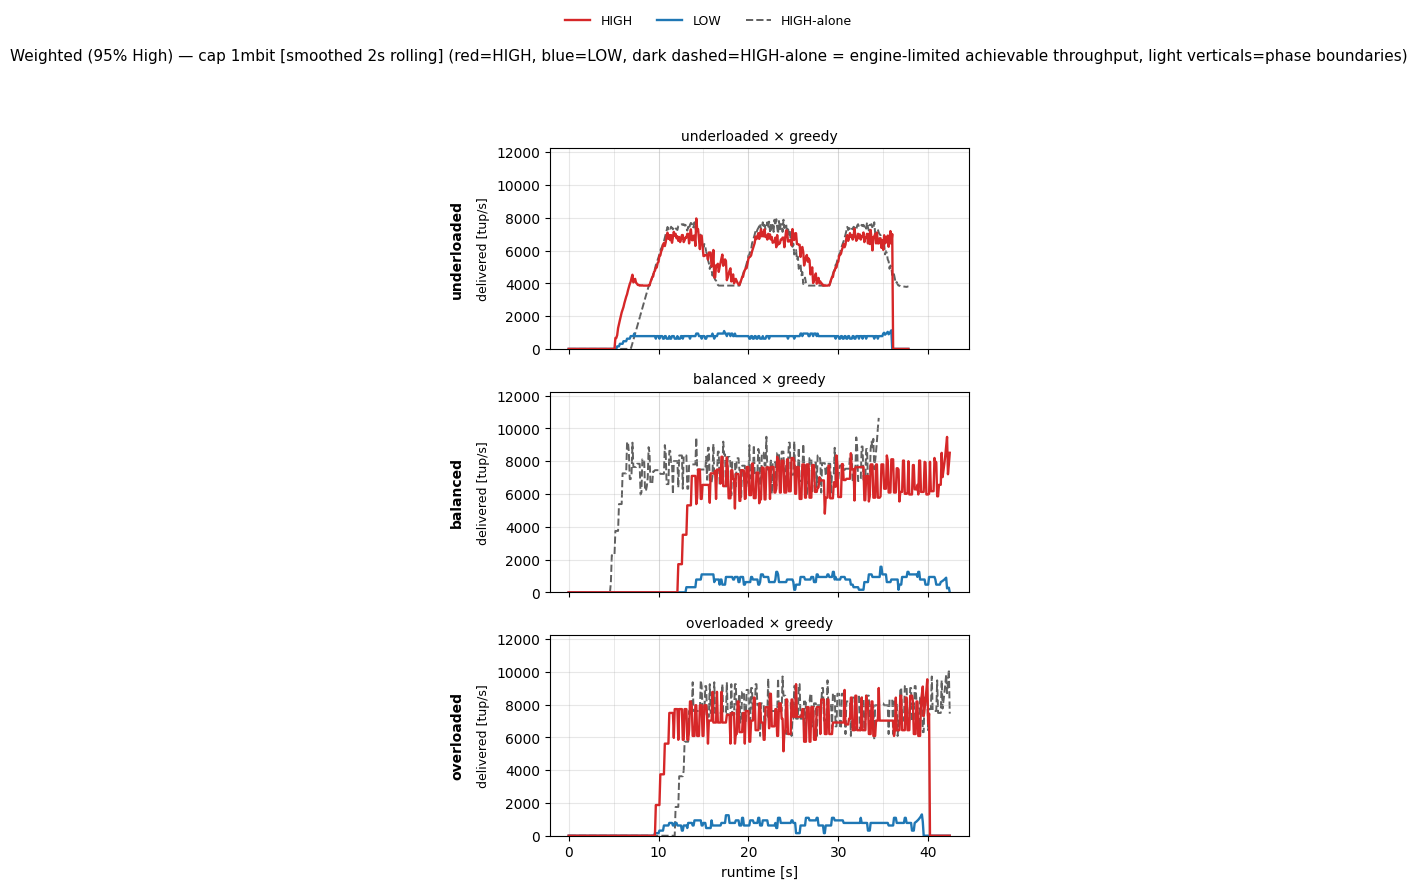

  wrote congestion_grid_1mbit_always_send.pdf


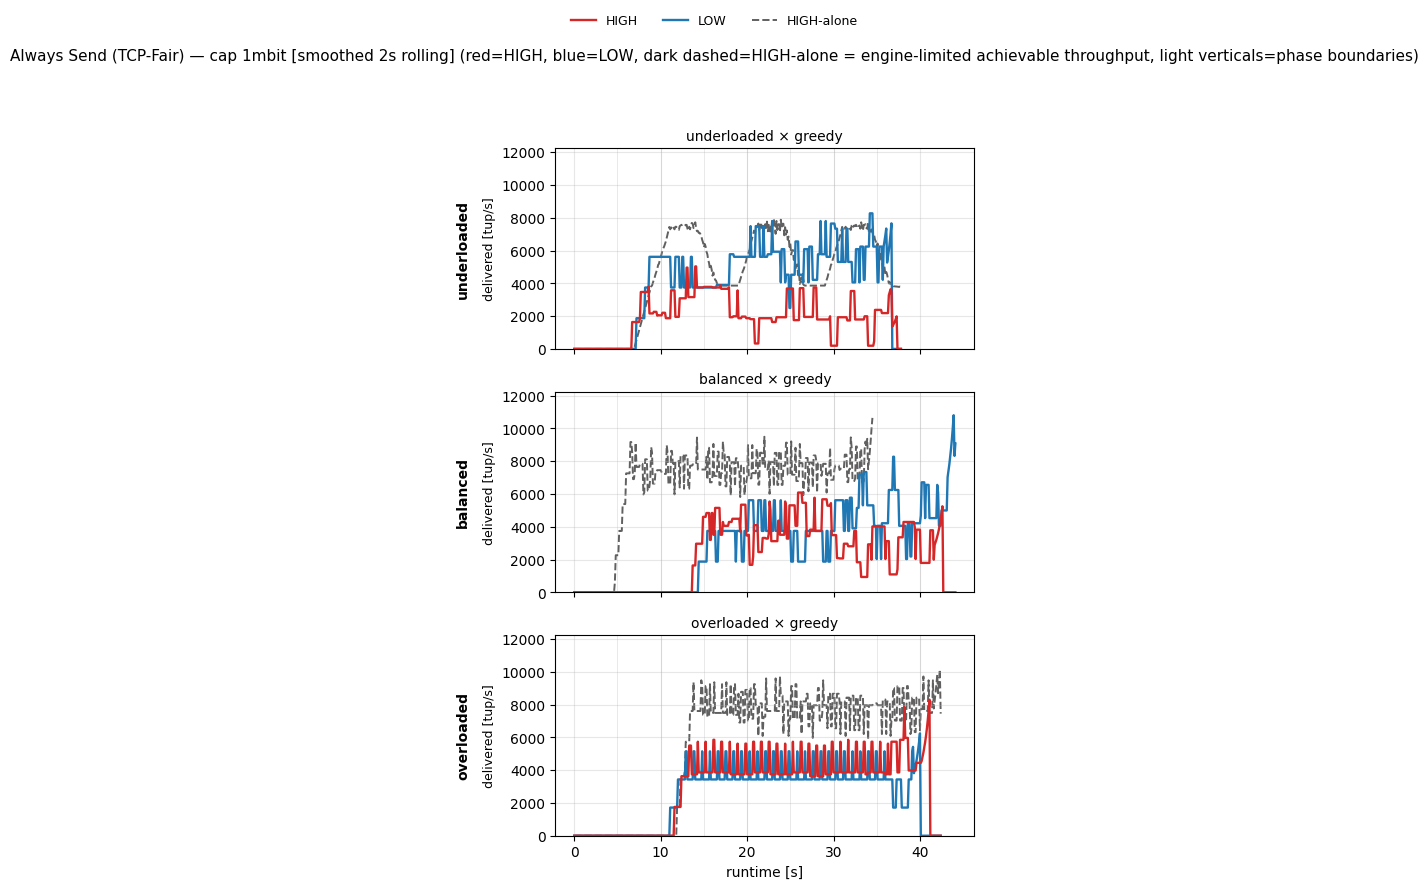

  wrote congestion_grid_none_weighted_strict.pdf


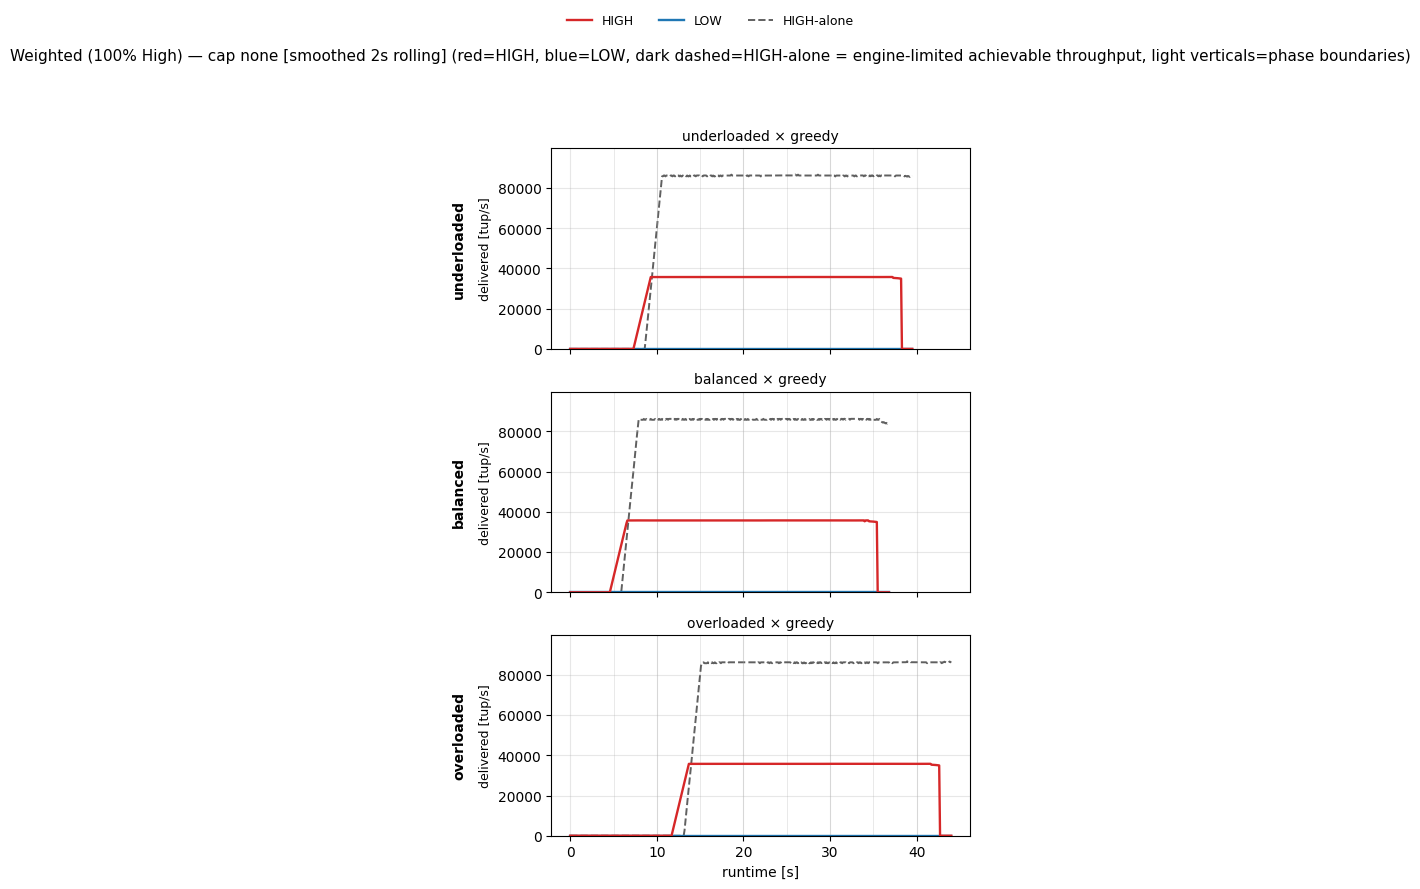

  wrote congestion_grid_none_weighted.pdf


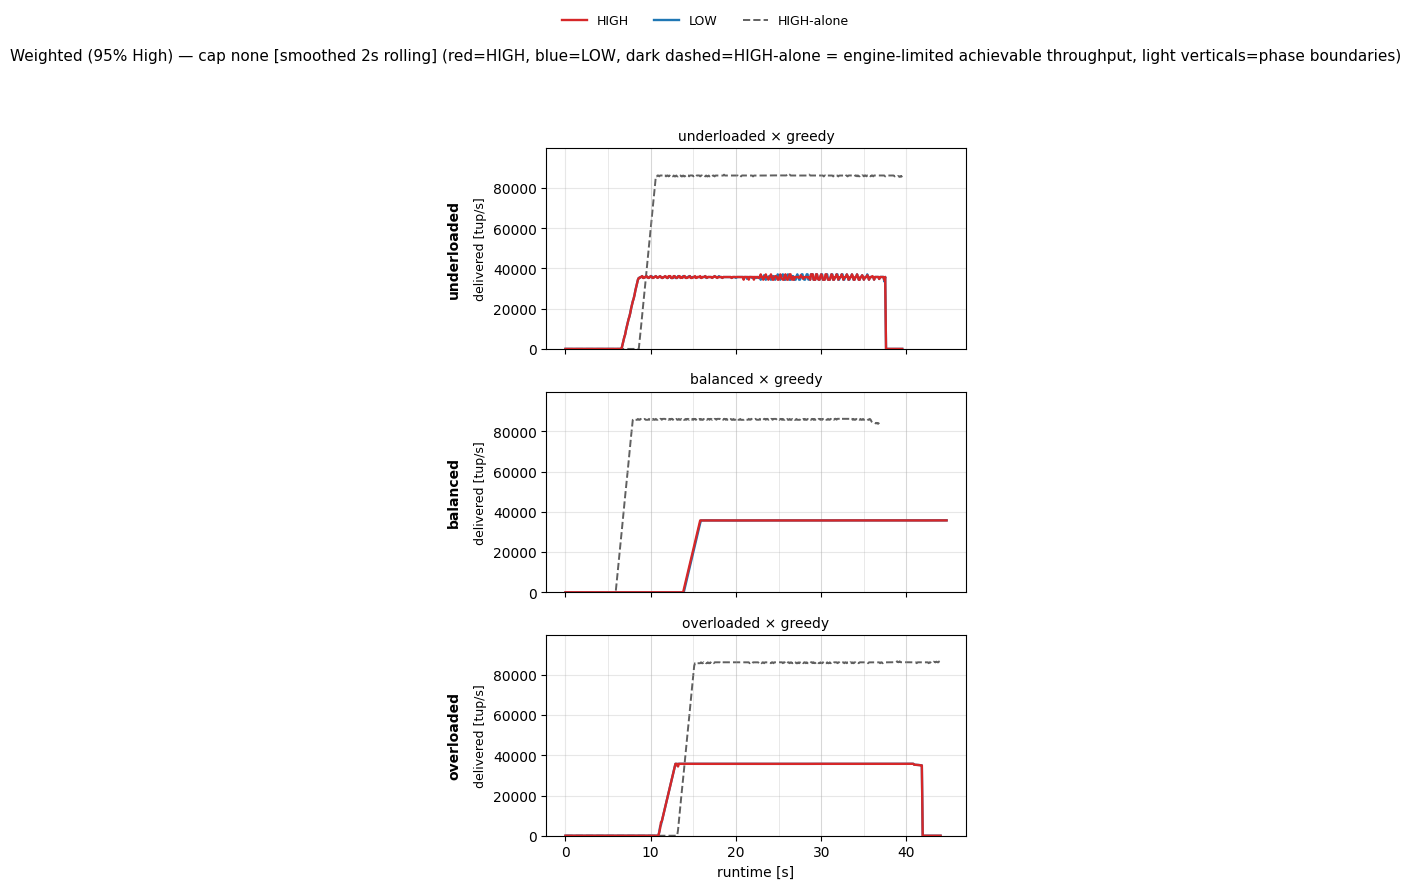

  wrote congestion_grid_none_always_send.pdf


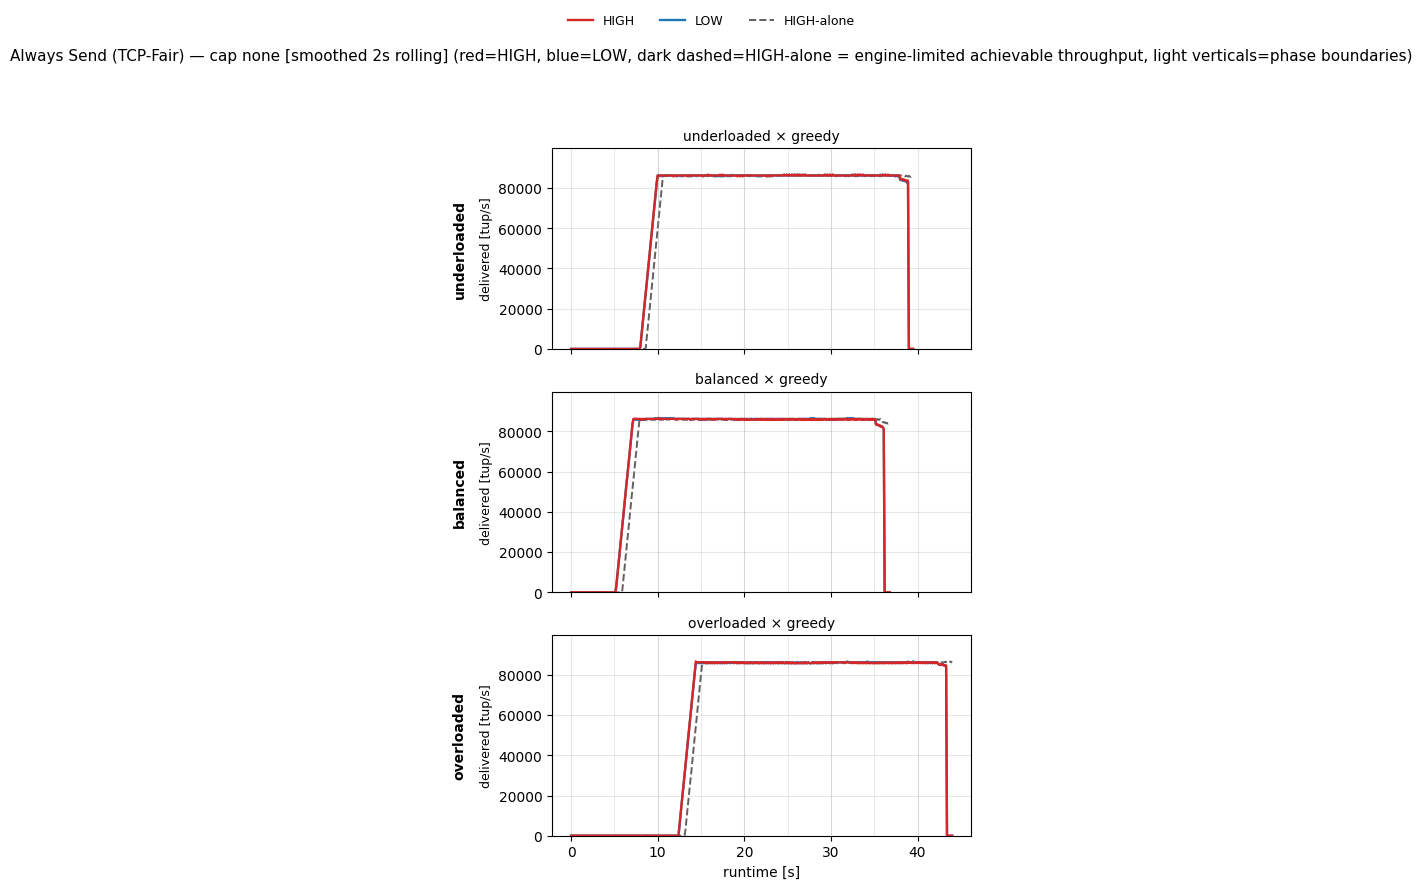

In [3]:
# Render one twin grid per (cap × policy). For each cap we save two PDFs so the comparison
# between policies is cell-aligned at the same wire capacity:
#   congestion_grid_<cap>_adaptive.pdf
#   congestion_grid_<cap>_always_send.pdf

caps_in_data = sorted(network_df['cap'].dropna().unique().tolist(), key=_cap_sort_key)
print(f'Rendering grids for caps: {caps_in_data}')

for cap in caps_in_data:
    for policy in POLICY_ORDER:
        fig = plot_grid(cap, policy, network_df, 'delivered_tuples_per_s')
        if fig is None:
            print(f'  skip (no data): cap={cap} policy={policy}')
            continue
        pol_key = {'WEIGHTED_STRICT': 'weighted_strict', 'WEIGHTED_PRIO': 'weighted', 'ALWAYS_SEND': 'always_send'}.get(policy, policy.lower())
        out_path = f'congestion_grid_{cap}_{pol_key}.pdf'
        fig.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f'  wrote {out_path}')
        plt.show()


In [4]:
# Shared headline-plot infrastructure used by the sojourn, throughput, and latency cells below.
# The headline figure is a (len(HEADLINE_ROWS) × len(HEADLINE_POLICIES)) grid — each column is a
# policy (WEIGHTED_STRICT / WEIGHTED_PRIO / ALWAYS_SEND), each row is a contention regime ordered
# top-down by increasing offered HIGH load: underloaded (HIGH well below cap), balanced (HIGH at
# cap during active phase), overloaded (HIGH always above cap). Labels follow standard queueing-
# theory vocabulary (ρ<1 / ρ≈1 / ρ>1) so readers outside the project parse them quickly.
#
# Each row label is annotated with ρ = (high_frac + low_frac) — the sum of HIGH's two staircase
# rates expressed as a fraction of the wire cap. ρ is computed per-row from the dataframe at
# render time, so it reflects whatever HIGH_STEP_CONFIGS the benchmark actually ran with.

HEADLINE_CAP = '1mbit'
HEADLINE_LOW = 'greedy'
# (internal_key, display_prefix). The internal_key is the high_label value stored in the CSVs by
# the benchmark driver (set in config.py: HIGH_STEP_CONFIGS) and must match it.
HEADLINE_ROWS = [
    ('underloaded', 'underloaded'),
    ('balanced',    'balanced'),
    ('overloaded',  'overloaded'),
]
HEADLINE_POLICIES = ['WEIGHTED_STRICT', 'WEIGHTED_PRIO', 'ALWAYS_SEND']
# Column header: main title (bold) + small italic subtitle rendered separately so the column
# header takes one bold line plus a smaller italic clarifier.
HEADLINE_POLICY_HEADERS = {
    # Display label + small italic subtitle. The new display labels already embed the ratio
    # (Weighted (100% High) / (95% High)) and the TCP-fair note, so the subtitle is empty for
    # all three policies — plot_headline's `if policy_subtitle:` guard skips the second line.
    'WEIGHTED_STRICT': (POLICY_DISPLAY_LABEL['WEIGHTED_STRICT'], ''),
    'WEIGHTED_PRIO':   (POLICY_DISPLAY_LABEL['WEIGHTED_PRIO'],   ''),
    'ALWAYS_SEND':     (POLICY_DISPLAY_LABEL['ALWAYS_SEND'],     ''),
}

# Curves whose last real sample lands MORE than this many seconds before the figure-global
# runtime_max are extended with synthetic zeros so the "no signal here" stretch is visible
# (e.g. WEIGHTED_STRICT balanced HIGH stops emitting block events after the warmup transient).
# Curves that end CLOSE to runtime_max are left alone so the natural trial-teardown attenuation
# isn't replaced by a hard vertical drop to zero.
ZERO_FILL_GAP_THRESHOLD_S = 10.0

# Auto-bottom pad: when y_bottom_override is not specified by the caller, the y-axis bottom is
# set to -Y_BOTTOM_PAD_FRACTION × y_top per row so a curve sitting at zero is lifted off the
# x-axis edge and remains visible. Scaled per row since y_top varies between regimes.
Y_BOTTOM_PAD_FRACTION = 0.04

# Hatch-overlay color for the scheduler-gated fill in stacked-block plots. Black (not the
# priority color) so the diagonal strokes contrast against the solid colored base layer — when
# both are the same color the hatch is invisible against the saturated fill.
STACK_HATCH_COLOR = 'black'


def _rho_for_row(sub_cap, high_label):
    """Compute ρ = (high_step_high_rate + high_step_low_rate) / cap_tps for the given HIGH config,
    reading rates from the dataframe (any row with this high_label works — rates are constant
    across rows of a config). Returns None if no rows match (so the caller can degrade gracefully).
    """
    rows = sub_cap[(sub_cap['high_label'] == high_label)
                   & sub_cap['high_step_high_rate'].notna()
                   & sub_cap['high_step_low_rate'].notna()
                   & sub_cap['max_network_rate_tuples_per_s'].notna()]
    if rows.empty:
        return None
    cap_tps = float(rows['max_network_rate_tuples_per_s'].iloc[0])
    if cap_tps <= 0:
        return None
    return (float(rows['high_step_high_rate'].iloc[0]) + float(rows['high_step_low_rate'].iloc[0])) / cap_tps


def _zero_fill_smart(curve, runtime_max, gap_threshold_s=ZERO_FILL_GAP_THRESHOLD_S):
    """Like _zero_fill but only extends the right edge when the data ends FAR before runtime_max.
    Empty curves still get a synthesized flat-zero series across the full range (so 'no events' is
    visible as a flat line). For non-empty curves whose last sample is within gap_threshold_s of
    runtime_max, returns the curve as-is — no hard vertical drop to zero at the trial-teardown
    boundary."""
    if curve.empty:
        return _zero_fill(curve, runtime_max)
    last_t = float(curve['runtime_s'].max())
    if runtime_max - last_t > gap_threshold_s:
        return _zero_fill(curve, runtime_max)
    return curve


def _align_stack_curves(base_curve, base_col, stack_curve, stack_col):
    """Outer-merge two (runtime_s, value) curves on runtime_s and zero-fill missing samples so
    fill_between can paint both layers on a common grid. Returns (t, base_values, stack_values)
    as numpy arrays sorted by runtime_s. Used by plot_headline's overlay-block rendering: the
    base layer (source-blocked) and overlay layer (scheduler-gated) come from different listeners
    and therefore have non-aligned time grids; we resample to the union of both grids.
    """
    base = base_curve.rename(columns={base_col: '_base'})[['runtime_s', '_base']]
    stack = stack_curve.rename(columns={stack_col: '_stack'})[['runtime_s', '_stack']]
    merged = base.merge(stack, on='runtime_s', how='outer').sort_values('runtime_s').fillna(0.0)
    return merged['runtime_s'].values, merged['_base'].values, merged['_stack'].values


def plot_headline(df_metric, value_col, ylabel, suptitle_metric_name, out_suffix,
                  y_top_override=None, y_bottom_override=None, y_tick_formatter=None,
                  stack_df=None, stack_value_col=None, stack_label_suffix='scheduler-gated',
                  base_label_suffix='source-blocked',
                  priorities=('HIGH', 'LOW'), show_high_alone=True):
    """Render the headline figure (len(HEADLINE_ROWS) × len(HEADLINE_POLICIES)) for a given metric.

    *y_top_override* controls the y-axis ceiling:
      - None        → auto-fit per row to max(HIGH-alone peak, contended peak) × Y_LIM_FACTOR_OVER_HIGH_ALONE
      - scalar      → same ceiling for every row
      - dict {row_label: scalar} → per-row override (e.g. {'overloaded': 1.0, 'balanced': 0.5}).
        Rows not in the dict fall back to the auto-fit value.

    *y_bottom_override* controls the y-axis floor:
      - None        → auto-compute as -Y_BOTTOM_PAD_FRACTION × y_top per row, so a curve sitting
                      at zero is lifted off the x-axis edge and remains visible
      - scalar      → same floor for every row (e.g. 0 to anchor at the axis, or a specific
                      negative value to override the auto-padding)

    Regardless of the floor, the bottom spine (the x-axis line and its tick labels) is pinned to
    y=0 so the zero line stays visually anchored — the negative pad opens up empty space below
    the axis line, giving curves sitting at zero a visible "above the axis" appearance.

    *y_tick_formatter* is an optional matplotlib FuncFormatter callable (val, pos)→str. Useful for
    compressing large numeric ranges (e.g. throughput formatted as 'k tup/s').

    *stack_df* / *stack_value_col*: when provided, the per-priority rendering switches from a line
    plot to a two-layer filled area where the second signal is **overlaid** (not stacked) onto
    the first. The base layer (df_metric[value_col], e.g. blocked_fraction) is drawn as a solid
    fill in the priority color from y=0 to base. The overlay layer (stack_df[stack_value_col],
    e.g. gated_fraction) is drawn as a black-hatched fill from y=0 to overlay value, on TOP of
    the base — so each layer stays bounded in [0, 1] individually. The two signals describe the
    same blocked time from different vantage points (the scheduler's applyPressure() closes the
    channel that the source then waits on), so stacking would double-count heavily and push the
    visible cap to 2.0. The hatch uses a contrasting black edge so the overlay is visible against
    the colored solid base (same-color hatch over saturated fill is invisible).

    *priorities*: which priorities to render. Defaults to both ('HIGH', 'LOW'); pass ('HIGH',) or
    ('LOW',) to render a single-priority figure (the blocked cell uses this to produce separate
    HIGH and LOW figures). The priority name is appended to the output filename when filtered so
    the two figures don't overwrite each other.

    *show_high_alone*: include the dashed HIGH-alone reference line. Defaults to True. Disable
    for metrics where HIGH-alone is not a meaningful baseline (e.g. block-fraction: HIGH-alone is
    near-zero by construction and adds clutter).
    """
    sub_cap = df_metric[df_metric['cap'] == HEADLINE_CAP]
    if sub_cap.empty:
        print(f'no data for cap={HEADLINE_CAP}')
        return None

    stack_sub_cap = None
    if stack_df is not None and stack_value_col is not None and not stack_df.empty:
        stack_sub_cap = stack_df[stack_df['cap'] == HEADLINE_CAP]
        if stack_sub_cap.empty:
            stack_sub_cap = None

    # HIGH-alone references and per-row y-axis ceiling.
    ha_by_row = {}
    y_top_by_row = {}
    for high_label, _ in HEADLINE_ROWS:
        ha_sub = sub_cap[(sub_cap['strategy'] == 'HIGH_ALONE') & (sub_cap['high_label'] == high_label)
                         & (sub_cap['priority'] == 'HIGH')]
        ha_curve = _smoothed_curve(ha_sub, value_col) if not ha_sub.empty else pd.DataFrame(columns=['runtime_s', value_col])
        ha_by_row[high_label] = ha_curve
        # HIGH-alone only drives the ceiling when it's actually rendered; otherwise let the
        # contended/stack curves set the auto-fit so we don't reserve vertical space for an
        # invisible reference.
        peak = float(ha_curve[value_col].max()) if (show_high_alone and not ha_curve.empty) else 0.0
        contended_peak = float(sub_cap[(sub_cap['high_label'] == high_label)
                                       & (sub_cap['low_label'] == HEADLINE_LOW)
                                       & (sub_cap['strategy'].isin(HEADLINE_POLICIES))
                                       & (sub_cap['priority'].isin(priorities))][value_col].max() or 0.0)
        # Overlay rendering: each layer is bounded individually in [0, 1], so the ceiling needs
        # to clear max(base, overlay) — not their sum. Stacking would push the cap to 2.0 when
        # both signals are saturated simultaneously, which physically happens under heavy
        # contention because the scheduler's applyPressure() closes the channel that the source
        # then waits on.
        stack_peak = 0.0
        if stack_sub_cap is not None:
            stack_peak = float(stack_sub_cap[(stack_sub_cap['high_label'] == high_label)
                                             & (stack_sub_cap['low_label'] == HEADLINE_LOW)
                                             & (stack_sub_cap['strategy'].isin(HEADLINE_POLICIES))
                                             & (stack_sub_cap['priority'].isin(priorities))]
                               [stack_value_col].max() or 0.0)
        auto_top = max(peak, contended_peak, stack_peak) * Y_LIM_FACTOR_OVER_HIGH_ALONE \
                   if (peak > 0 or contended_peak > 0 or stack_peak > 0) else THROUGHPUT_Y_LIM_FALLBACK

        if isinstance(y_top_override, dict):
            y_top_by_row[high_label] = y_top_override.get(high_label, auto_top)
        elif y_top_override is not None:
            y_top_by_row[high_label] = y_top_override
        else:
            y_top_by_row[high_label] = auto_top

    # Figure-global runtime_max — longest observed runtime_s across all panels (and HIGH-alone
    # overlays). Used so curves with significantly truncated data (e.g. WEIGHTED_STRICT balanced
    # HIGH) get their flat-zero tail rendered, while curves that end close to this max are left
    # alone (avoiding the hard trial-teardown vertical drop).
    global_runtime_max = float(sub_cap['runtime_s'].max() or 0.0)
    if stack_sub_cap is not None:
        global_runtime_max = max(global_runtime_max, float(stack_sub_cap['runtime_s'].max() or 0.0))
    if show_high_alone:
        for ha_curve in ha_by_row.values():
            if not ha_curve.empty:
                global_runtime_max = max(global_runtime_max, float(ha_curve['runtime_s'].max()))

    n_rows = len(HEADLINE_ROWS)
    n_cols = len(HEADLINE_POLICIES)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.2 * n_rows),
                             sharex=True, sharey='row', squeeze=False)

    for r, (high_label, row_title_prefix) in enumerate(HEADLINE_ROWS):
        ha_curve = ha_by_row[high_label]
        y_top = y_top_by_row[high_label]
        # Per-row y_bottom: auto-pad below zero (proportional to y_top) unless the caller pinned
        # an explicit floor. This lifts a flat-zero curve off the x-axis so it's still visible.
        if y_bottom_override is None:
            y_bottom = -Y_BOTTOM_PAD_FRACTION * y_top
        else:
            y_bottom = y_bottom_override

        for c, policy in enumerate(HEADLINE_POLICIES):
            ax = axes[r, c]
            cell = sub_cap[(sub_cap['strategy'] == policy)
                           & (sub_cap['high_label'] == high_label)
                           & (sub_cap['low_label'] == HEADLINE_LOW)]
            stack_cell = None
            if stack_sub_cap is not None:
                stack_cell = stack_sub_cap[(stack_sub_cap['strategy'] == policy)
                                           & (stack_sub_cap['high_label'] == high_label)
                                           & (stack_sub_cap['low_label'] == HEADLINE_LOW)]

            runtime_max = global_runtime_max

            # Phase boundaries: pull period_high/period_low from any row in the same regime
            # (constant within a high_label), so empty cells still get the staircase verticals.
            ph_src = sub_cap[(sub_cap['high_label'] == high_label)
                             & sub_cap['high_step_period_high'].notna()
                             & sub_cap['high_step_period_low'].notna()]
            if not ph_src.empty:
                for tb in _phase_boundaries(float(ph_src['high_step_period_high'].iloc[0]),
                                            float(ph_src['high_step_period_low'].iloc[0]),
                                            runtime_max):
                    ax.axvline(tb, linestyle='-', color='lightgray', alpha=0.5, linewidth=0.7, zorder=0)

            # HIGH / LOW curves. For empty cells (e.g. WEIGHTED_STRICT underloaded blocked, where
            # neither HIGH nor LOW emitted events), _zero_fill_smart synthesizes a flat-zero line
            # so the panel renders with the same axis layout as the others (no "(no data)" gap).
            for prio in priorities:
                prio_rows = cell[cell['priority'] == prio]
                pcurve = _smoothed_curve(prio_rows, value_col) if not prio_rows.empty else pd.DataFrame(columns=['runtime_s', value_col])
                pcurve = _zero_fill_smart(pcurve, runtime_max)
                if stack_cell is not None:
                    # Overlay rendering: source-blocked as solid fill from 0 to base in the
                    # priority color; scheduler-gated as a BLACK-hatched fill from 0 to overlay
                    # drawn ON TOP of the solid layer (facecolor='none' = no fill, just hatch
                    # strokes). Each layer stays in [0, 1] — the two signals describe the same
                    # blocked time from different vantage points, so stacking double-counts.
                    # Black hatch (not the priority color) so the diagonal strokes contrast
                    # against the saturated colored base.
                    stack_prio_rows = stack_cell[stack_cell['priority'] == prio]
                    gcurve = (_smoothed_curve(stack_prio_rows, stack_value_col)
                              if not stack_prio_rows.empty
                              else pd.DataFrame(columns=['runtime_s', stack_value_col]))
                    gcurve = _zero_fill_smart(gcurve, runtime_max)
                    if pcurve.empty and gcurve.empty:
                        continue
                    if pcurve.empty:
                        pcurve = pd.DataFrame({'runtime_s': gcurve['runtime_s'], value_col: 0.0})
                    if gcurve.empty:
                        gcurve = pd.DataFrame({'runtime_s': pcurve['runtime_s'], stack_value_col: 0.0})
                    t, base_vals, stack_vals = _align_stack_curves(pcurve, value_col, gcurve, stack_value_col)
                    ax.fill_between(
                        t, 0.0, base_vals,
                        color=PRIORITY_COLORS[prio], alpha=0.55, linewidth=0,
                        label=f'{prio} {base_label_suffix}',
                        zorder=3 if prio == 'HIGH' else 2,
                    )
                    ax.fill_between(
                        t, 0.0, stack_vals,
                        facecolor='none', edgecolor=STACK_HATCH_COLOR, hatch='///',
                        linewidth=0.0, alpha=0.95,
                        label=f'{prio} {stack_label_suffix}',
                        zorder=4 if prio == 'HIGH' else 3,
                    )
                else:
                    if not pcurve.empty:
                        ax.plot(pcurve['runtime_s'], pcurve[value_col],
                                label=prio, color=PRIORITY_COLORS[prio], linewidth=1.8,
                                zorder=3 if prio == 'HIGH' else 2)

            # HIGH-alone reference.
            if show_high_alone:
                ha_to_plot = _zero_fill_smart(ha_curve, runtime_max)
                if not ha_to_plot.empty:
                    ax.plot(ha_to_plot['runtime_s'], ha_to_plot[value_col],
                            label='HIGH-alone', color=HIGH_ALONE_COLOR, linewidth=1.4,
                            linestyle='--', alpha=0.85, zorder=1)

            # Column header (only on the top row): policy name (bold) + small italic subtitle.
            if r == 0:
                policy_name, policy_subtitle = HEADLINE_POLICY_HEADERS.get(policy, (policy, ''))
                ax.set_title(policy_name, fontsize=11, fontweight='bold', pad=18)
                if policy_subtitle:
                    ax.annotate(policy_subtitle, xy=(0.5, 1.02), xycoords='axes fraction',
                                ha='center', va='bottom', fontsize=8, fontstyle='italic')
            if r == n_rows - 1:
                ax.set_xlabel('runtime [s]')
            ax.set_ylim(top=y_top, bottom=y_bottom)
            ax.set_xlim(left=0, right=runtime_max)
            # Pin the bottom spine (the visible x-axis line and its tick labels) to y=0. The
            # ylim still extends below 0 (per y_bottom), opening up empty visual space under the
            # spine. Curves sitting at zero are drawn on the spine and remain visible "above the
            # x-axis edge" of the panel.
            ax.spines['bottom'].set_position(('data', 0))
            ax.grid(True, alpha=0.2)
            if y_tick_formatter is not None:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(y_tick_formatter))

        # Row annotation: descriptor + ρ value computed from dataframe.
        rho = _rho_for_row(sub_cap, high_label)
        row_title = f'{row_title_prefix} (ρ = {rho:.2g})' if rho is not None else row_title_prefix
        axes[r, 0].set_ylabel(ylabel, fontsize=9)
        axes[r, 0].annotate(row_title, xy=(-0.22, 0.5), xycoords='axes fraction',
                            ha='center', va='center', rotation=90, fontsize=10, fontweight='bold')

    # Figure-level legend, top-center above the column headers — won't overlap with data.
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=len(handles),
                   bbox_to_anchor=(0.5, 0.99), fontsize=9, frameon=False)

    # Tight suptitle — smoothing detail moves to the cell comment / paper caption. Positioned at
    # y=0.94 with tight_layout rect=[0, 0, 1, 0.90] to give the legend (y=0.99) breathing room
    # above the title.
    fig.suptitle(f'{suptitle_metric_name} — cap {HEADLINE_CAP}', fontsize=12, y=0.94)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    # Tag the filename with the priority filter when the caller restricts it so HIGH and LOW
    # figures don't overwrite each other.
    prio_tag = f"_{'-'.join(priorities)}" if tuple(priorities) != ('HIGH', 'LOW') else ''
    out_path = f'headline_{out_suffix}_{HEADLINE_CAP}_{HEADLINE_LOW}{prio_tag}.pdf'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'wrote {out_path}')
    return fig


wrote headline_sojourn_1mbit_greedy.pdf


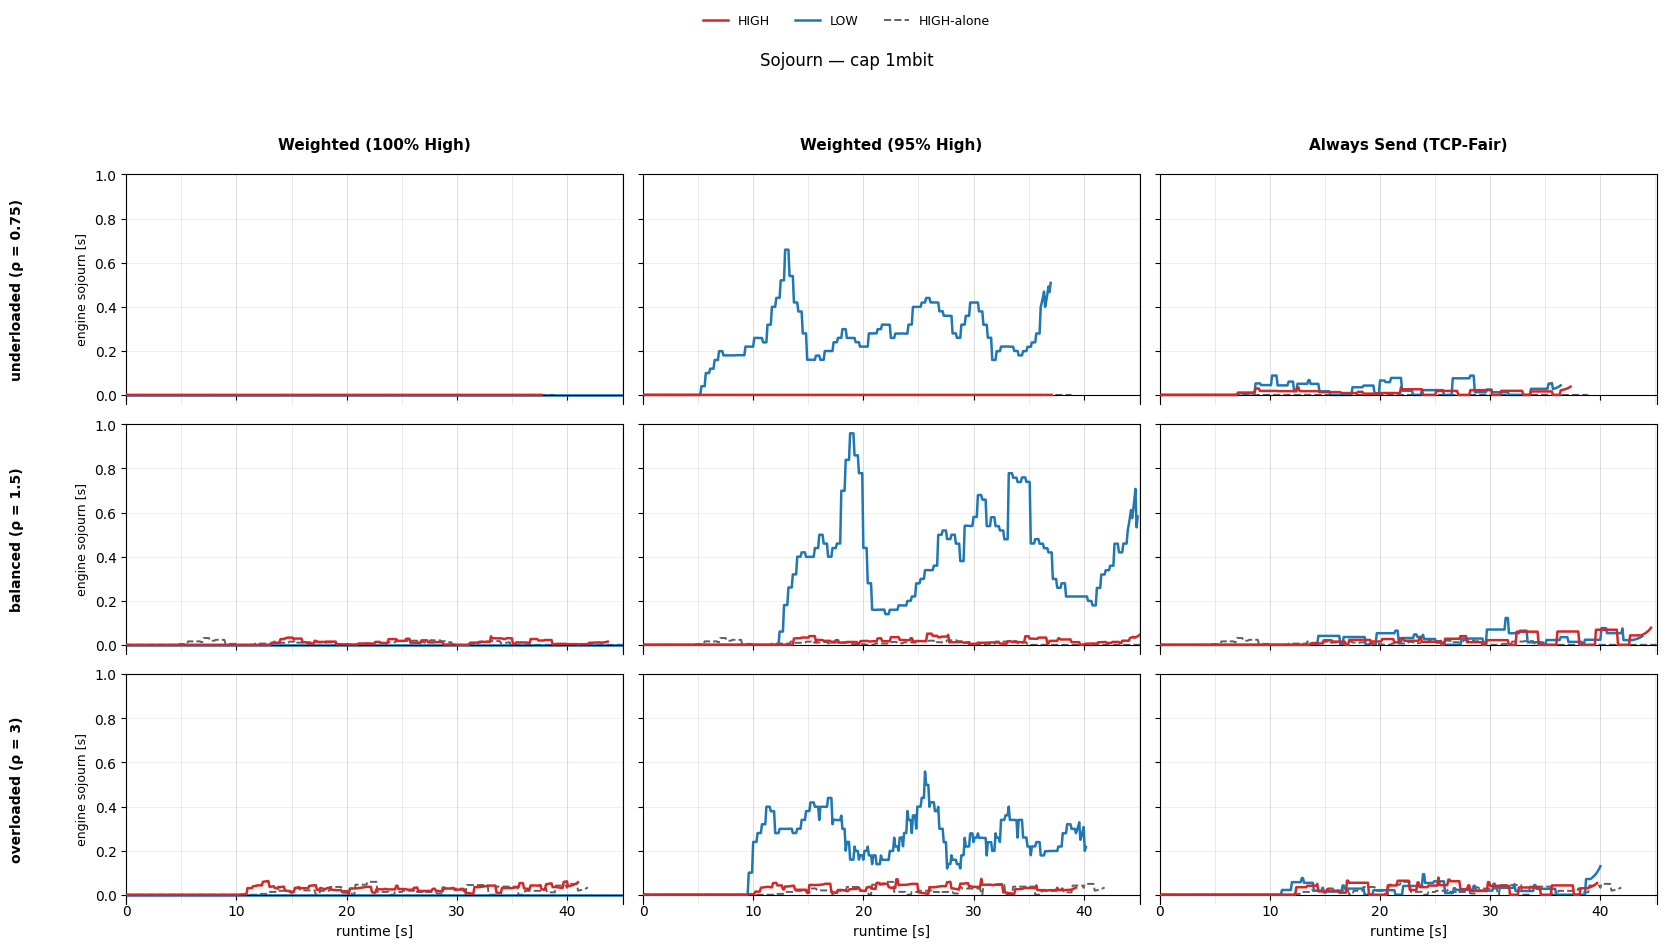

In [5]:
# Sojourn headline: same layout as the throughput and latency headlines, but plotting engine-side
# buffer sojourn time (seconds) per priority. Sojourn = (NetworkSink::execute Ok timestamp) -
# (NetworkSink::execute first-arrival timestamp) — captures backpressure + scheduler-gate retries +
# Full-induced retries. Does NOT include Rust mpsc dequeue or TCP wire time (send_buffer returns at
# enqueue). This is the metric that priority scheduling actually affects.
#
# Expected qualitative pattern at overloaded × greedy / 1mbit:
#   WEIGHTED_STRICT HIGH ≈ HIGH-alone   (HIGH is never gated)
#   WEIGHTED_PRIO HIGH   ≈ HIGH-alone × small constant   (gated rarely under 0.95 weight)
#   WEIGHTED_PRIO LOW    >> HIGH-alone  (gated most of the time)
#   ALWAYS_SEND HIGH ≈ ALWAYS_SEND LOW  (no priority — both queue behind each other; but note
#       the queue is upstream of NetworkSink under ALWAYS_SEND, so this metric understates it)

if sojourn_df.empty:
    print('No sojourn data — re-run the benchmark with the BufferSojournEvent pipeline to populate sojourn_timeseries.csv.')
else:
    fig_sojourn = plot_headline(sojourn_df, 'sojourn_seconds',
                                 ylabel='engine sojourn [s]',
                                 suptitle_metric_name='Sojourn',
                                 out_suffix='sojourn',
                                 y_top_override=1)
    if fig_sojourn is not None:
        plt.show()


wrote headline_latency_1mbit_greedy.pdf


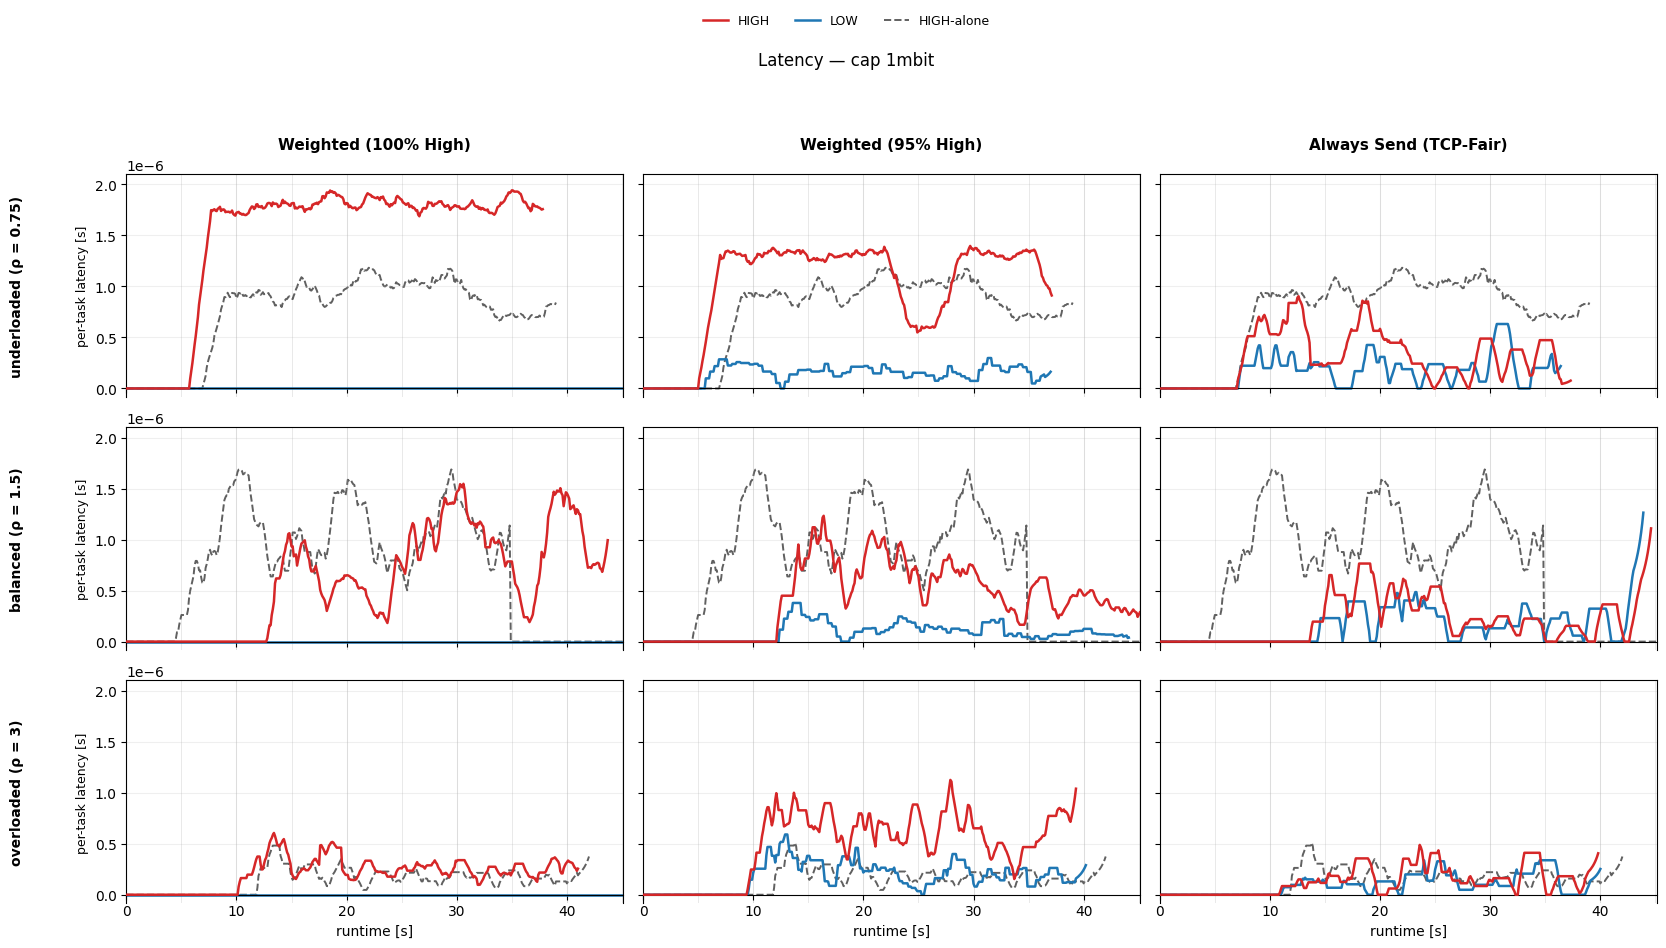

In [6]:
# Latency headline: same layout as the sojourn and throughput headlines, but plotting the per-task
# `latency_seconds` metric from the LatencyListener. Note: this is per-task pipeline execution time
# (Nautilus-compiled task wall-clock), NOT end-to-end network latency. Included alongside the
# throughput and sojourn headlines for completeness; the primary "policy supports HIGH/LOW" argument
# is carried by the throughput plot.

if latency_df.empty:
    print('No latency data in latency_timeseries.csv.')
else:
    fig_latency = plot_headline(latency_df, 'latency_seconds',
                                 ylabel='per-task latency [s]',
                                 suptitle_metric_name='Latency',
                                 out_suffix='latency',
                                 y_top_override=2.1e-6)
    if fig_latency is not None:
        plt.show()


wrote headline_throughput_1mbit_greedy.pdf


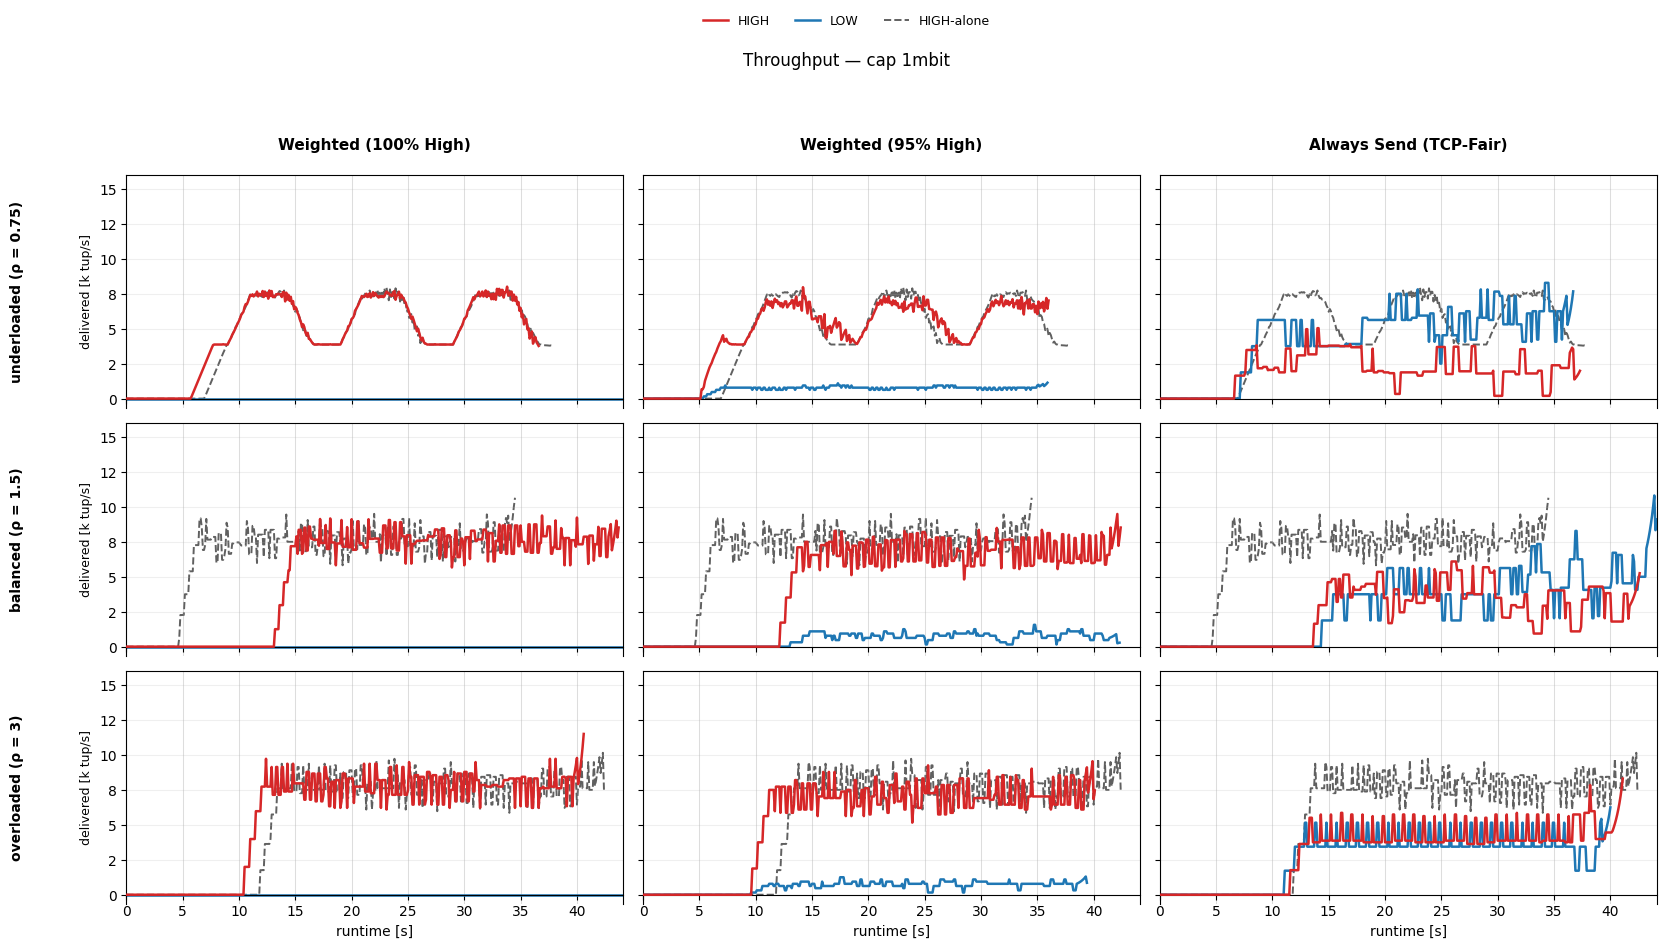

In [7]:
# Throughput headline: policy comparison across contention regimes (overloaded / balanced /
# underloaded × greedy). Renders the 3×3 figure used in the paper. Y-axis uses thousand-units
# (k tup/s) so the tick labels fit in the same horizontal space the sojourn / blocked plots
# would normally use.

fig_thr = plot_headline(network_df, 'delivered_tuples_per_s',
                        ylabel='delivered [k tup/s]',
                        suptitle_metric_name='Throughput',
                        out_suffix='throughput',
                        y_top_override=16000,
                        y_tick_formatter=lambda val, pos: f'{val / 1000:.0f}')
if fig_thr is not None:
    plt.show()


wrote headline_throughput_selection_greedy.pdf


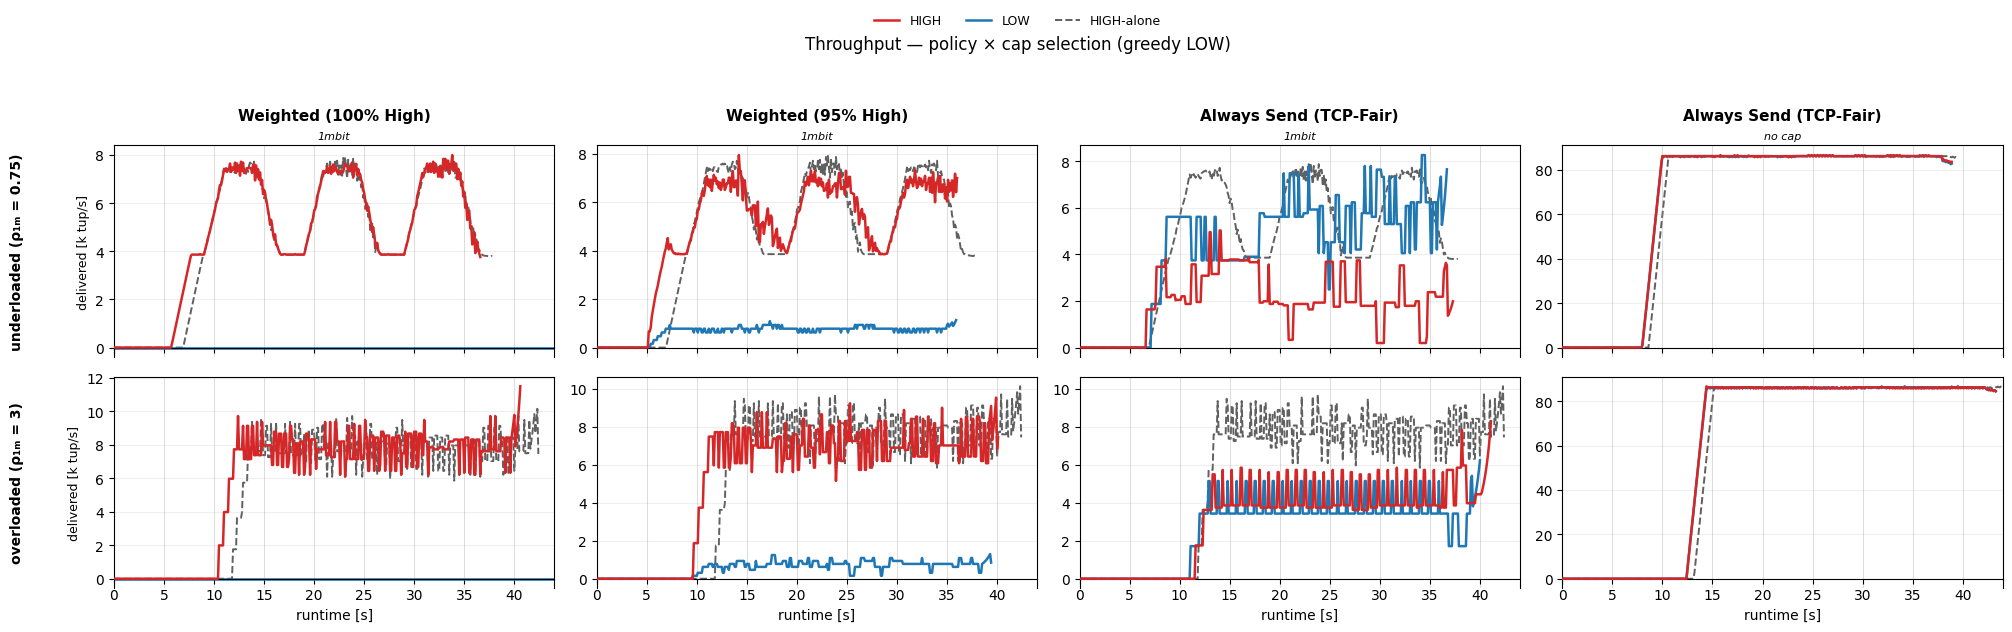

In [8]:
# Throughput selection headline — 2×4 grid mixing two caps:
#   rows = regime: underloaded, overloaded
#   cols = (cap, policy):
#       (1mbit, WEIGHTED_STRICT)
#       (1mbit, WEIGHTED_PRIO)
#       (1mbit, ALWAYS_SEND)
#       (none,  ALWAYS_SEND)     ← "no cap" — the runner stores it as cap='none' (matches the
#                                   --caps none CLI option that skips the tc throttle phase)
# Every cell is rendered, including WS @ 1mbit / overloaded — the strict-priority starvation
# regime (LOW = 0 throughout) is visualized directly rather than blanking the panel.
#
# Each panel has its OWN y-axis (sharey=False, and y_top computed per (cap, regime, policy)).
# This makes the HIGH-vs-LOW height ratio within a panel honest, but means the reader CANNOT
# directly compare absolute throughput across panels — the y-axis scale changes per panel.
# The cap-group is stated explicitly in the column subtitle and via the row's ρ annotation, so
# the distinction stays textually clear without needing a visual separator.
#
# Requires EXPERIMENT_CAPS in scripts/benchmarking/network_sink/config.py to include "none"
# (or pass --caps 1mbit,none on the CLI). Otherwise, the right column will render empty axes.

SELECTION_LOW = 'greedy'
SELECTION_ROWS = ['underloaded', 'overloaded']
SELECTION_COLS = [
    ('1mbit', 'WEIGHTED_STRICT'),
    ('1mbit', 'WEIGHTED_PRIO'),
    ('1mbit', 'ALWAYS_SEND'),
    ('none',  'ALWAYS_SEND'),
]
SELECTION_HEADERS = {
    # Display label uses the renamed policies (POLICY_DISPLAY_LABEL embeds the weight ratio
    # and the TCP-fair note); subtitle keeps the cap context so the cap-group is unambiguous
    # even when columns sit side-by-side.
    ('1mbit', 'WEIGHTED_STRICT'): (POLICY_DISPLAY_LABEL['WEIGHTED_STRICT'], '1mbit'),
    ('1mbit', 'WEIGHTED_PRIO'):   (POLICY_DISPLAY_LABEL['WEIGHTED_PRIO'],   '1mbit'),
    ('1mbit', 'ALWAYS_SEND'):     (POLICY_DISPLAY_LABEL['ALWAYS_SEND'],     '1mbit'),
    ('none',  'ALWAYS_SEND'):     (POLICY_DISPLAY_LABEL['ALWAYS_SEND'],     'no cap'),
}


def _selection_high_alone(cap, high_label, value_col):
    """ HIGH_ALONE reference curve for one (cap, regime). Used as the dashed overlay and as one
    input to the per-panel y-axis ceiling. Returns an empty frame when no HIGH_ALONE rows exist
    (e.g., when the benchmark didn't include the no-cap HIGH_ALONE — the panel still renders
    without the dashed line in that case)."""
    ha_sub = network_df[(network_df['cap'] == cap)
                        & (network_df['strategy'] == 'HIGH_ALONE')
                        & (network_df['high_label'] == high_label)
                        & (network_df['priority'] == 'HIGH')]
    return _smoothed_curve(ha_sub, value_col) if not ha_sub.empty else pd.DataFrame(columns=['runtime_s', value_col])


def _panel_y_top(cap, high_label, policy, value_col):
    """ Per-PANEL y-axis ceiling: max of HIGH-alone peak and this (cap, regime, policy) cell's
    peak, scaled by Y_LIM_FACTOR_OVER_HIGH_ALONE. Independent per panel — no sharing across
    columns or rows."""
    ha_curve = _selection_high_alone(cap, high_label, value_col)
    ha_peak = float(ha_curve[value_col].max()) if not ha_curve.empty else 0.0
    cell_peak = float(network_df[(network_df['cap'] == cap)
                                 & (network_df['high_label'] == high_label)
                                 & (network_df['low_label'] == SELECTION_LOW)
                                 & (network_df['strategy'] == policy)]
                      [value_col].max() or 0.0)
    auto = max(ha_peak, cell_peak) * Y_LIM_FACTOR_OVER_HIGH_ALONE
    return auto if auto > 0 else THROUGHPUT_Y_LIM_FALLBACK


def plot_headline_selection():
    value_col = 'delivered_tuples_per_s'

    # Figure-global runtime_max from the panels we actually render, to keep all x-axes aligned.
    relevant = network_df[
        ((network_df['cap'] == '1mbit') & (network_df['strategy'].isin(['HIGH_ALONE', 'WEIGHTED_STRICT', 'WEIGHTED_PRIO', 'ALWAYS_SEND'])))
        | ((network_df['cap'] == 'none')  & (network_df['strategy'].isin(['HIGH_ALONE', 'ALWAYS_SEND'])))
    ]
    relevant = relevant[relevant['high_label'].isin(SELECTION_ROWS)]
    # `.max()` on an empty series (or a frame where every panel's selection is empty) returns
    # NaN, and `float(NaN or 0.0) == NaN` because NaN is truthy in Python — the original
    # `or 0.0` fallback only kicks in for the zero / None case, not the NaN case. Guard
    # explicitly so an empty CSV doesn't blow up inside _zero_fill's `int(NaN * 1000)`.
    runtime_max_raw = relevant['runtime_s'].max() if 'runtime_s' in relevant.columns else None
    if runtime_max_raw is None or pd.isna(runtime_max_raw) or runtime_max_raw <= 0:
        print('plot_headline_selection: no rows matched the cap+strategy+high_label filter; '
              'skipping render. Re-run the benchmark with EXPERIMENT_CAPS containing 1mbit '
              'and/or none.')
        return None
    runtime_max = float(runtime_max_raw)

    n_rows = len(SELECTION_ROWS)
    n_cols = len(SELECTION_COLS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 3.2 * n_rows),
                             sharex=True, sharey=False, squeeze=False)

    for r, high_label in enumerate(SELECTION_ROWS):
        for c, (cap, policy) in enumerate(SELECTION_COLS):
            ax = axes[r, c]

            # Phase boundaries — staircase verticals; the same for both caps within a regime.
            ph_src = network_df[(network_df['high_label'] == high_label)
                                & network_df['high_step_period_high'].notna()
                                & network_df['high_step_period_low'].notna()]
            if not ph_src.empty:
                for tb in _phase_boundaries(float(ph_src['high_step_period_high'].iloc[0]),
                                            float(ph_src['high_step_period_low'].iloc[0]),
                                            runtime_max):
                    ax.axvline(tb, linestyle='-', color='lightgray', alpha=0.5,
                               linewidth=0.7, zorder=0)

            cell = network_df[(network_df['cap'] == cap)
                              & (network_df['strategy'] == policy)
                              & (network_df['high_label'] == high_label)
                              & (network_df['low_label'] == SELECTION_LOW)]

            # HIGH / LOW curves. Empty rows synthesize a flat-zero series so WS-overloaded LOW
            # is rendered as a visible flat line at zero (instead of just missing).
            for prio in ('HIGH', 'LOW'):
                prio_rows = cell[cell['priority'] == prio]
                pcurve = (_smoothed_curve(prio_rows, value_col)
                          if not prio_rows.empty
                          else pd.DataFrame(columns=['runtime_s', value_col]))
                pcurve = _zero_fill_smart(pcurve, runtime_max)
                if not pcurve.empty:
                    # Both lines drawn semi-transparent so when they overlap (notably
                    # ALWAYS_SEND / no-cap, where TCP fair-share gives HIGH ≈ LOW) the
                    # bottom curve blends through instead of being completely hidden.
                    ax.plot(pcurve['runtime_s'], pcurve[value_col],
                            label=prio, color=PRIORITY_COLORS[prio], linewidth=1.8,
                            alpha=0.7,
                            zorder=3 if prio == 'HIGH' else 2)

            # HIGH-alone dashed reference (per cap).
            ha_curve = _zero_fill_smart(_selection_high_alone(cap, high_label, value_col), runtime_max)
            if not ha_curve.empty:
                ax.plot(ha_curve['runtime_s'], ha_curve[value_col],
                        label='HIGH-alone', color=HIGH_ALONE_COLOR, linewidth=1.4,
                        linestyle='--', alpha=0.85, zorder=1)

            # Surface "no data yet for this (cap, policy)" so an empty no-cap column doesn't
            # look like a plotting bug. Triggers when the benchmark hasn't been re-run with
            # EXPERIMENT_CAPS = ["1mbit", "none"] yet.
            if cell.empty and ha_curve.empty:
                ax.text(0.5, 0.5, f'no data\ncap={cap}, policy={policy}',
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=10, color='#888', style='italic')

            # Per-PANEL y-axis ceiling — independent per (cap, regime, policy).
            y_top = _panel_y_top(cap, high_label, policy, value_col)
            #ax.set_ylim(top=y_top, bottom=-Y_BOTTOM_PAD_FRACTION * y_top)
            ax.set_xlim(left=0, right=runtime_max)
            ax.spines['bottom'].set_position(('data', 0))
            ax.grid(True, alpha=0.2)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _p: f'{v / 1000:.0f}'))

            if r == 0:
                title, subtitle = SELECTION_HEADERS[(cap, policy)]
                ax.set_title(title, fontsize=11, fontweight='bold', pad=18)
                ax.annotate(subtitle, xy=(0.5, 1.02), xycoords='axes fraction',
                            ha='center', va='bottom', fontsize=8, fontstyle='italic')
            if r == n_rows - 1:
                ax.set_xlabel('runtime [s]')

        axes[r, 0].set_ylabel('delivered [k tup/s]', fontsize=9)

        # Row label — regime name + ρ computed from the 1mbit cap (ρ is undefined for the
        # no-cap column, so we tag the ρ with the cap it was derived from).
        rho = _rho_for_row(network_df[network_df['cap'] == '1mbit'], high_label)
        row_label = f'{high_label} (ρ₁ₘ = {rho:.2g})' if rho is not None else high_label
        axes[r, 0].annotate(row_label, xy=(-0.22, 0.5), xycoords='axes fraction',
                            ha='center', va='center', rotation=90, fontsize=10, fontweight='bold')

    # Single figure-level legend above the column headers.
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=len(handles),
                   bbox_to_anchor=(0.5, 0.99), fontsize=9, frameon=False)

    fig.suptitle('Throughput — policy × cap selection (greedy LOW)', fontsize=12, y=0.94)
    fig.tight_layout(rect=[0, 0, 1, 0.90])

    out_path = f'headline_throughput_selection_{SELECTION_LOW}.pdf'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'wrote {out_path}')
    return fig


fig_sel = plot_headline_selection()
if fig_sel is not None:
    plt.show()

wrote headline_blocked_1mbit_greedy_HIGH.pdf


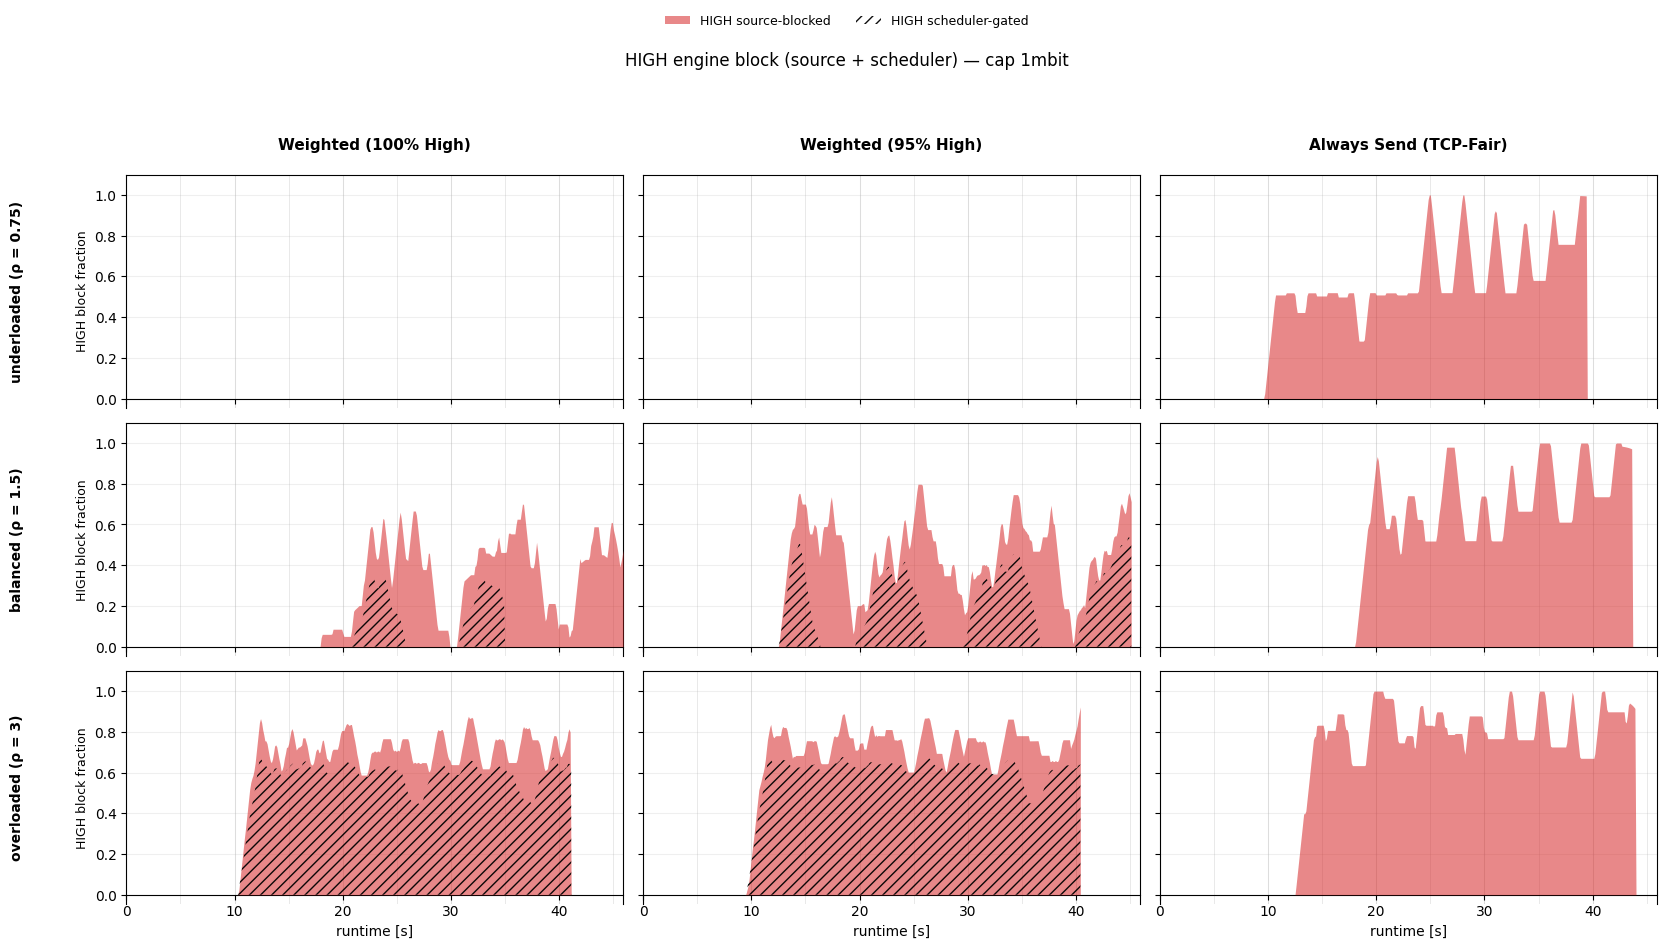

wrote headline_blocked_1mbit_greedy_LOW.pdf


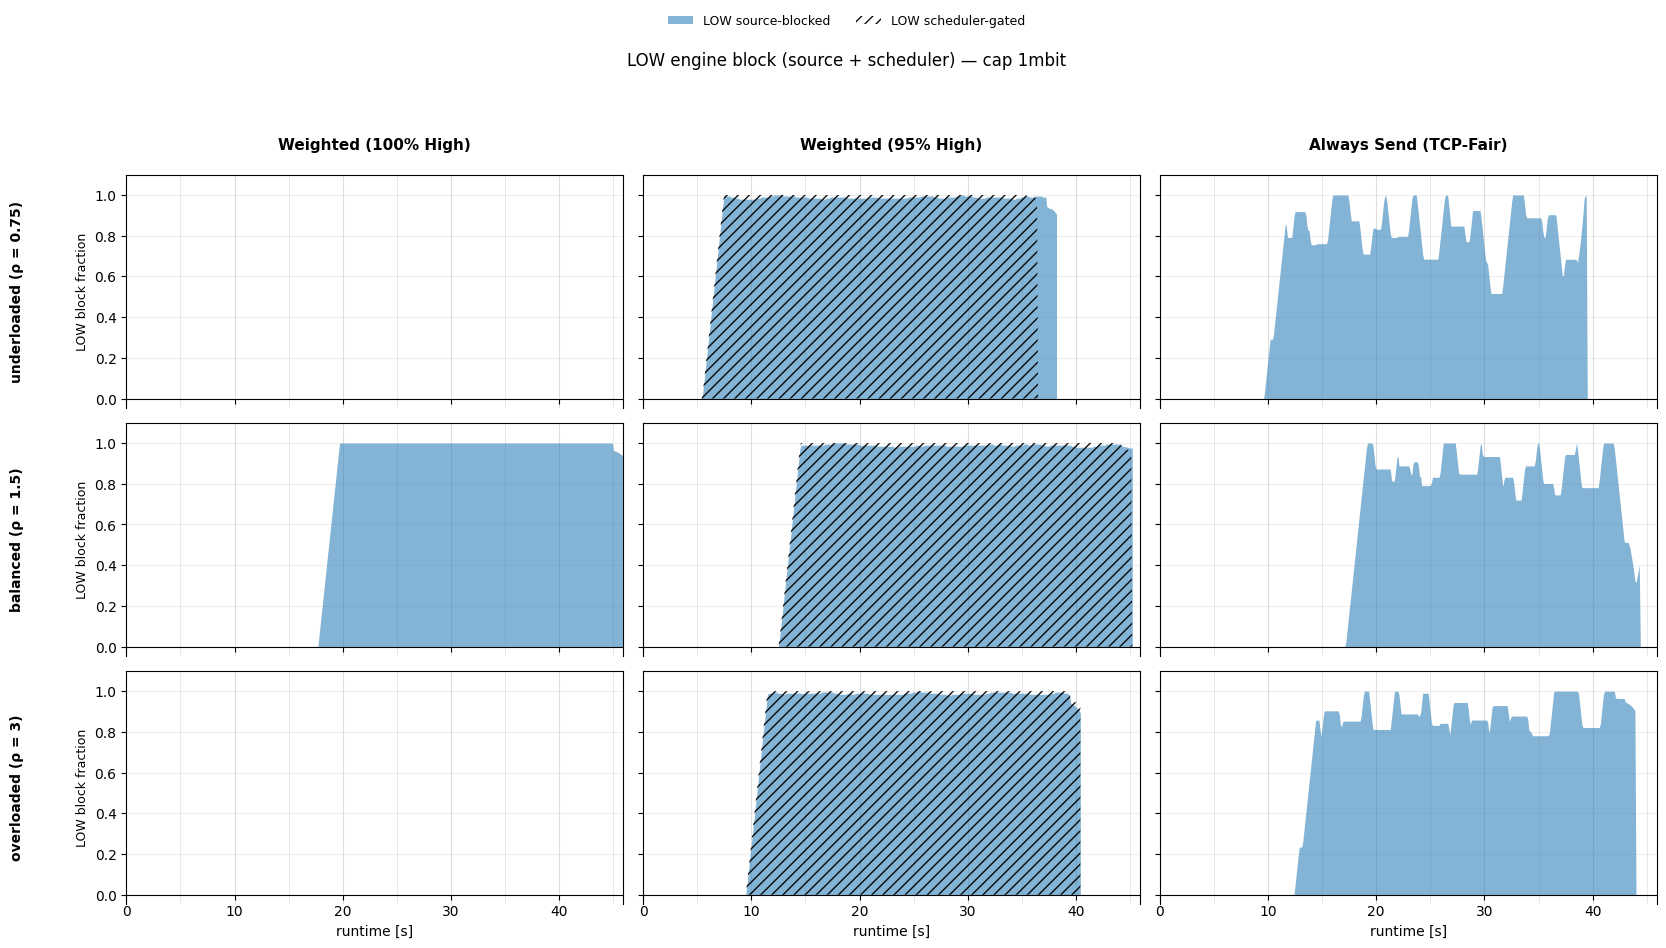

In [9]:
# Combined block headline: per-priority overlaid filled area — base (solid) is source-side
# BackpressureBlocked fraction (BackpressureListener::wait), overlay (hatched) is sink-side
# SchedulerGated fraction (AdaptiveSendingScheduler deny/retry loops). Together they describe
# the engine-side wait per priority and disambiguate the two block types under the WEIGHTED
# policies, where source-blocked alone is blind to scheduler gating (under WEIGHTED_STRICT
# overloaded × greedy, LOW emits zero blocked events but is continuously gated).
#
# The two signals are *overlaid* (not stacked) because they describe the same blocked time from
# different vantage points — the scheduler's applyPressure() closes the channel that the source
# then waits on, so they're heavily correlated and stacking would double-count. Each layer is
# bounded individually in [0, 1].
#
# Rendered as two separate figures (HIGH and LOW) because stacking both priorities into the same
# panel doubled the visual load and made the per-priority decomposition hard to read. HIGH-alone
# is omitted from these plots — it's a throughput/sojourn baseline, not a block-fraction one.
#
# Expected qualitative pattern at overloaded × greedy / 1mbit:
#   WEIGHTED_STRICT HIGH ≈ solid red (source-blocked); little/no hatched
#   WEIGHTED_STRICT LOW  ≈ hatched blue (scheduler-gated); little/no solid
#   WEIGHTED_PRIO HIGH   ≈ solid red with hatched on top during gated stretches
#   WEIGHTED_PRIO LOW    ≈ hatched blue with solid underneath during source-side waits
#   ALWAYS_SEND HIGH/LOW ≈ solid (no gating in this policy)
#
# Smoothing caveat: plot_headline applies a 2 s rolling-mean (SMOOTHING_WINDOW_SAMPLES = 20
# windows of 100 ms each), tuned for throughput. Both fraction-style signals are closer to binary
# (blocked / not-blocked), so the smoother averages bursts: a 200 ms block episode reads as ≈ 0.1
# in the smoothed curve. Sustained episodes under contention still read ≈ 1.0; transient ones
# appear smaller than they actually are.

if blocked_df.empty:
    print('No blocked-time data — re-run the benchmark with the BackpressureBlockedEvent pipeline to populate blocked_timeseries.csv.')
else:
    for prio in ('HIGH', 'LOW'):
        fig_blocked = plot_headline(
            blocked_df, 'blocked_fraction',
            ylabel=f'{prio} block fraction',
            suptitle_metric_name=f'{prio} engine block (source + scheduler)',
            out_suffix='blocked',
            y_top_override=1.1,
            stack_df=gated_df,
            stack_value_col='gated_fraction',
            priorities=(prio,),
            show_high_alone=False,
        )
        if fig_blocked is not None:
            plt.show()
